## Aperçu du cours
Ce cours vise à fournir une introduction à la manipulation de données au travers de la programmation. Nous verrons ensemble :
- Une initiation à la programmation ***Python***
- La prise en main des environnements de type ***Jupyter Notebook***
- La découverte des librairies de manipulation de données:
    - Numpy
    - Pandas
    - Matplotlib
    - Seaborn
- Explorer des jeux de données différents

En matière d'organisation, l'intervention - d'un total de 6h - sera divisée en trois cours de 2h chacun.
| ~~**Mercredi 1 avril (10h-12h)**~~ | ~~**Mercredi 8 Avril (10h-12h)**~~ | **Mercredi 22 Avril (10h-12h)** |
|:-------------------------------:|:-------------------------------:|:-------------------------------:|
| ~~Introduction du cours et carnets ***Jupyter***~~|  ~~Manipuler ses données : Numpy, Pandas~~ | Exploration d'un jeu de données  |
|~~Introduction à ***Python***~~ |  ~~Visualiser ses données : Matplotlib, Seaborn~~    | Questions  |

## Import des librairies et du dataset

Nous allons désormais essayer de récapituler l'ensemble de ce que nous avons vu sur les deux premiers cours en explorant un jeu de données intitulé "*vico (La vie en confinement)*" et réalisé pendant la crise du COVID en 2020, à l'issu du premier confinement. 

Il a été réalisé par une équipe de [**chercheur·euses**](https://enqueteconfinement.wixsite.com/site/a-propos-de-nous). Cette étude avait pour but d'étudier les relations sociales et les diverses formes de solidarité durant la période de confinement. La population étudiée comprends l'ensemble des personnes résidant dans une commune français et étant agés de plus de 18 ans. Elle a donné lieu à un échantillon très vaste de plus de 16 000 personnes. 


Les [**résultats**](https://enqueteconfinement.wixsite.com/site/resultats-de-l-enquete) de l'étude et [**une partie des données**](https://vico.hypotheses.org/donnees) issues du questionnaire est disponible en libre accès. L'ensemble des données est disponible sur Progedo [**10.13144/lil-1488**](https://data.progedo.fr/studies/doi/10.13144/lil-1488).


Les données en accès libre ne contienne pas l'ensemble des variables de l'étude et surtout contienne que 2000 individus piochés au hasard dans le jeu de données contenant 16 000 individus.

In [2]:
import pandas as pd
pd.set_option("display.max_columns", None) #Astuce pour afficher toutes les colonnes

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("Data/vico2020.csv", sep=";", encoding="utf-8")
df.head()

,ID,SEXE,AGE,SITCONJ,RESNB,RESISOL,LOGAUTRE,MASQUE,TEMPS,INQUIET,VOISINS,CONTROL,AMIS,FAMILLE,POL,DIPLONIV,SITPROF_rec,PCS_rec6,REV,POIDS_init
0,1,Une femme,30,Non,1,"Oui, autant que je voulais","Non, je suis toujours dans mon logement habituel.",Non sélectionné,"Non, je ne manque pas du tout de temps libre",Non sélectionné,Non sélectionné,"Non, jamais",Ni plus ni moins,Plus souvent,Je ne me retrouve pas dans ces catégories,Un diplôme universitaire correspondant à plus ...,A la recherche d'un emploi,Cadres et professions intellectuelles supérieures,Moins de 800 euros par mois,"0,234182274477927"
1,2,Une femme,30,Non,5,"Oui, mais pas autant que je voulais","Non, je suis toujours dans mon logement habituel.",Non sélectionné,"Oui, je manque un peu de temps libre",Oui,Oui,"Oui, une seule fois",Moins souvent,Plus souvent,Au centre,Un diplôme universitaire correspondant à moins...,En études,Cadres et professions intellectuelles supérieures,Moins de 800 euros par mois,"0,745062357991611"
2,3,Une femme,24,Non,2,"Oui, autant que je voulais","Non, je suis toujours dans mon logement habituel.",Oui,"Non, je ne manque pas vraiment de temps libre",Non sélectionné,Non sélectionné,"Non, jamais",Plus souvent,Ni plus ni moins,A gauche,Un diplôme universitaire correspondant à plus ...,A la recherche d'un emploi,Cadres et professions intellectuelles supérieures,6000 euros par mois et plus,"0,231058550429964"
3,4,Une femme,45,Oui,2,"Oui, autant que je voulais","Non, je suis toujours dans mon logement habituel.",Non sélectionné,"Non, je ne manque pas du tout de temps libre",Non sélectionné,Non sélectionné,"Non, jamais",Plus souvent,Plus souvent,A gauche,Un diplôme universitaire correspondant à moins...,En emploi,Professions intermédiaires,De 5000 euros à moins de 6000 euros par mois,"0,56208272289024"
4,5,Une femme,57,Non,1,"Oui, autant que je voulais","Non, je suis toujours dans mon logement habituel.",Non sélectionné,"Non, je ne manque pas vraiment de temps libre",Non sélectionné,Non sélectionné,"Non, jamais",Ni plus ni moins,Ni plus ni moins,Ni à gauche ni à droite,Un diplôme universitaire correspondant à plus ...,En emploi,Cadres et professions intellectuelles supérieures,De 3000 euros à moins de 4000 euros par mois,"0,206141606141521"


## Intitulé des colonnes

 **Intitulé**    | **Question**                                                                                          |
|:--------------:|:-----------------------------------------------------------------------------------------------------:|
| SEXE           | Vous êtes ?...                                                                                        |
| AGE            | Quelle est votre année de naissance ?                                                                 |
| SITCONJ        |Vie en couple (recodage en 2 catégories - OUI/NON/NA)                                                  |
|RESNB           |VOUS Y COMPRIS, combien de personnes résidaient habituellement dans votre logement, avant le début du,confinement ? Comptez toutes les personnes dont votre logement habituel est la résidence principale, y compris les enfants en garde alternée.                                                                                               |
|RESISOL         |Disposiez-vous dans votre logement habituel, avant le confinement, d’une pièce ou d’un endroit où vous pouviez vous isoler, être au calme ?                                                                                     |
|LOGAUTRE        |Depuis le début du confinement, avez-vous quitté votre logement habituel pour un autre logement ?      |
|MASQUE          |[Porter un masque] Actuellement, et en dehors du travail, vous arrive-t-il de prendre certaines des dispositions suivantes pour vous protéger de la contamination ? Vous pouvez cocher autant de réponses que vous souhaitez.|
|TEMPS           |Depuis le début du confinement, avez-vous le sentiment de manquer de temps libre ?                     |
|INQUIET         |[Inquiet(e)] Depuis le début du confinement, y a-t-il eu des moments où vous vous êtes senti(e) ?. . . Vous pouvez cocher autant de réponses que vous souhaitez.                                                                |
|VOISINS         |[De discuter avec des voisins ou des personnes avec qui vous n’êtes pas en relation habituellement.]Depuis le début du confinement, est-ce qu’il vous est déjà arrivé ? Vous pouvez cocher autant de réponses que vous souhaitez.                                                                                                               |
|CONTROL         |Depuis le début du confinement, vous est-il arrivé d’être contrôlé(e) par la police ou la gendarmerie ?|
|AMIS            |Depuis le début du confinement, dans l’ensemble, êtes vous plus ou moins en contact avec vos amis ou ceux de votre conjoint qu’à l’habitude (par téléphone, par messages ou face à face)?                                     |
|FAMILLE         |Depuis le début du confinement, dans l’ensemble, êtes-vous plus ou moins en contact avec les membres de votre famille ou ceux de votre conjoint qu’à l’habitude (par téléphone, par messages ou face à face)?                    |
|POL             |En matière de politique, on classe habituellement les Français(es) sur une échelle qui va de la gauche à la droite. Vous personnellement, où vous classeriez-vous sur cette échelle ?                                           |
|DIPLONIV        |Quel est le niveau de diplôme le plus élevé que vous avez obtenu ?                                     |
|SITPROF_rec     |Situation professionnelle (recodage en 7 catégories)                                                   |
|PCS_rec6        |Catégorie socioprofessionnelle (recodage en 6 catégories)                                              |
|REV             |En prenant en compte tous les types de revenus de tous les membres de votre ménage, quel est actuellement le montant mensuel des ressources de l’ensemble du ménage ? N’oubliez pas de compter aussi les revenus de votre conjoint et de toutes les personnes avec lesquelles vous avez déclaré vivre habituellement. Il s’agit des revenus nets (de cotisations sociales et de C.S.G) avant impôts. Si les revenus sont fluctuants, faites une moyenne sur l’année.                                                                                                                 |
|POIDS_init      |Coefficent de pondération individuel                                                                   |


# Première approche du jeu de donnée

In [4]:
df["POIDS_init"] = df["POIDS_init"].str.replace(",", ".").astype(float)
df["POIDS_init"].head()

0    0.234182
1    0.745062
2    0.231059
3    0.562083
4    0.206142
Name: POIDS_init, dtype: float64

In [5]:
df.shape

(2000, 20)

On peut le formuler plus clairement:


In [6]:
print(f"Il y a {df.shape[0]} individus et {df.shape[1]} colonnes.")

Il y a 2000 individus et 20 colonnes.


Si maintenant on regarde plus en détail les données:

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 20 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           2000 non-null   int64  
 1   SEXE         2000 non-null   str    
 2   AGE          2000 non-null   int64  
 3   SITCONJ      1995 non-null   str    
 4   RESNB        2000 non-null   int64  
 5   RESISOL      1995 non-null   str    
 6   LOGAUTRE     2000 non-null   str    
 7   MASQUE       2000 non-null   str    
 8   TEMPS        1990 non-null   str    
 9   INQUIET      2000 non-null   str    
 10  VOISINS      2000 non-null   str    
 11  CONTROL      1989 non-null   str    
 12  AMIS         1989 non-null   str    
 13  FAMILLE      1994 non-null   str    
 14  POL          1980 non-null   str    
 15  DIPLONIV     1989 non-null   str    
 16  SITPROF_rec  2000 non-null   str    
 17  PCS_rec6     1859 non-null   str    
 18  REV          1965 non-null   str    
 19  POIDS_init   2000

Quelques remarques sont dors et déjà possible:

- La très grande majorités des variables sont des *string*. Seul *ID*, *AGE* et *RESNB* sont induqé comme des entiers
- On remarque également que *POIDS_init* est encodé comme une *string* alors qu'il s'agit d'un réel.
- On peut dire aussi que même la plupart des variables n'ont pas de valeurs nulles (absences de réponses), certaines en ont, bien qu'elles soient très marginales. On pourra éventuellement exclure les individus avec des valeurs manquantes.

Autre remarque plus générale, nous n'avons pas ici de question ouverte, mais c'est très souvent la cas dans des questionnaire. Ces questions pour être analysée de façon statistique demande de faire intervenir d'autres technique d'analyse textuel.

Si vous êtes intéressés pour compléter, n'hésitez pas à vous renseigner sur la textométrie, les concepts de tokenisation et lemmatisation, la mesure du TF-IDF, ou encore l'analyse de sentiment ! (Vous pouvez me demander si besoin !)

On peut également enlever la variable "ID" qui n'apportera pas d'informations intéressantes et ne peut être être utilisés comme variable quantitative.

In [8]:
df.drop(["ID"], axis=1, inplace=True)

## Le genre

In [9]:
df["SEXE"].value_counts()

SEXE
Une femme    1462
Un homme      538
Name: count, dtype: int64

In [10]:
df["SEXE"].value_counts(normalize=True).mul(100).round(1).astype(str) + '%'

SEXE
Une femme    73.1%
Un homme     26.9%
Name: proportion, dtype: str

On voit bien ici la forte disparité entre les deux modalités, puisque les personnes ayant répondu "Une femme" représente 3/4 des répondant·es. Il faut néanmoins prendre ce chiffre avec prudence car comme nous l'avons dit précédemment le jeu de données auquel nous n'avons accès ne représente que 12,5% du jeu de données total. On peut imaginer que tirage aléatoire des individus prenne en compte des caractéristiques de l'échantillon.

Contenu de l'absence d'information sur le sujet nous allons partir du principe, pour des raisons pédagogiques, que c'est le cas.

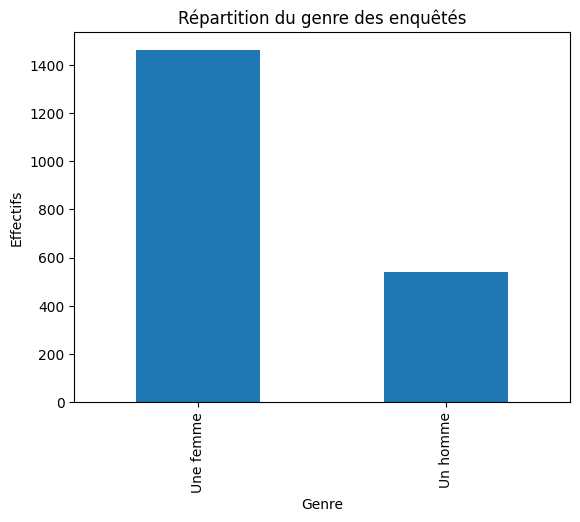

In [11]:
plt.figure()
df["SEXE"].value_counts().sort_values(ascending=False).plot(kind='bar')

plt.xlabel("Genre")
plt.ylabel("Effectifs")
plt.title("Répartition du genre des enquêtés")

plt.show()

## L'âge

Nous allons maintenant nous intéresser à l'âge des enquêtés. La première chose que nous pouvons effectué est d'afficher les différents indicateurs.

In [12]:
df.describe()

,AGE,RESNB,POIDS_init
count,2000.000000,2000.000000,2000.000000
mean,44.448500,2.580500,0.995351
std,14.471353,1.286603,0.881778
min,18.000000,1.000000,0.188401
25%,33.000000,2.000000,0.356939
50%,44.000000,2.000000,0.695011
75%,55.250000,4.000000,1.321763
max,74.000000,13.000000,6.033236


Nous pouvons balayer rapidement la distribution des valeurs

In [13]:
df["AGE"].value_counts().sort_index()

AGE
18     8
19    14
20    26
21    28
22    22
23    40
24    45
25    30
26    42
27    33
28    38
29    42
30    42
31    39
32    49
33    40
34    50
35    38
36    53
37    35
38    47
39    44
40    53
41    39
42    37
43    41
44    45
45    58
46    49
47    44
48    40
49    44
50    49
51    42
52    44
53    40
54    37
55    33
56    35
57    28
58    36
59    32
60    30
61    29
62    27
63    23
64    26
65    43
66    26
67    24
68    34
69    21
70    21
71    18
72    14
73    15
74    18
Name: count, dtype: int64

On peut mettre en évidence deux éléments: 

- La moyenne et la médiane sont relativement égales. Cela montre que la distribution des valeurs est bien répartie.
- C'est confirmé par la visualisation de la distribution des valeurs qui est moindre pour les valeurs extrêmes mais reste bien répartie.

Il est possible pour s'en assurer encore davantage de représenter la répartitio des âges sur un histogramme

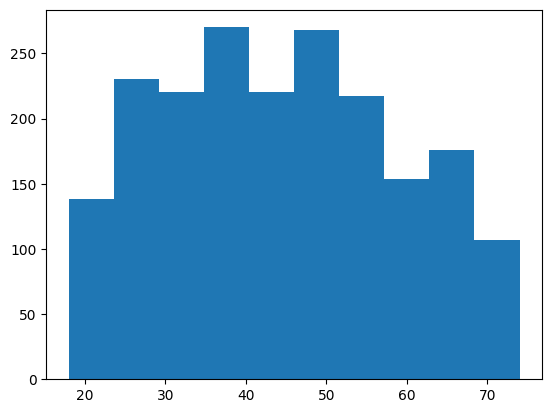

In [14]:
plt.figure()
plt.hist(df["AGE"])
plt.show()

Nous avons une répartion en cloche mais celle-ci reste écrasée.

Une autre manière de mieux visualiser cette représentation est de regrouper les valeurs par tranche d'âge.

In [15]:
df["AGE"] = pd.cut(df["AGE"], bins=[17, 29, 39, 49, 59, 69, 75], 
       labels= ['18-29', '30-39', '40-49', '50-59', '60-69', '70-74'], right=False)

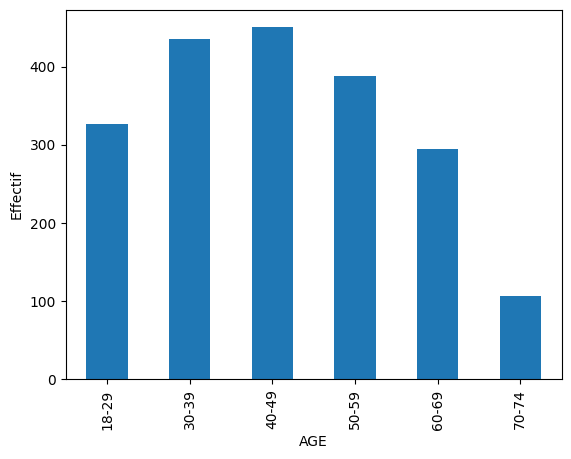

In [16]:
plt.figure()
df["AGE"].value_counts().sort_index().plot(kind='bar')
plt.ylabel("Effectif")
plt.show()

La répartition des âges est dorénavant plus simple à lire. La répartion en cloche est davantage marquée.

## Recodage

On peut remarquer rapidement que certaines modalités de l'enquête sont très longues. Exemple:

In [17]:
df["DIPLONIV"].value_counts()

DIPLONIV
Un diplôme universitaire correspondant à plus de 4 années d'études supérieures après le baccalauréat (maîtrise, DEA, DES    704
Un diplôme universitaire correspondant à moins de 4 années d'études supérieures après le baccalauréat (par exemple : DUT    694
Le baccalauréat                                                                                                             332
Le certificat d'études ou un diplôme de l'enseignement secondaire autre que le baccalauréat (par exemple : CAP, BEP, Bre    236
Aucun diplôme                                                                                                                23
Name: count, dtype: int64

Bien que le recodage ne soit pas obligatoire, il est néanmoins préférable de le faire par soucis de lisibilité, comme nous pouvons le voir ci-dessous:

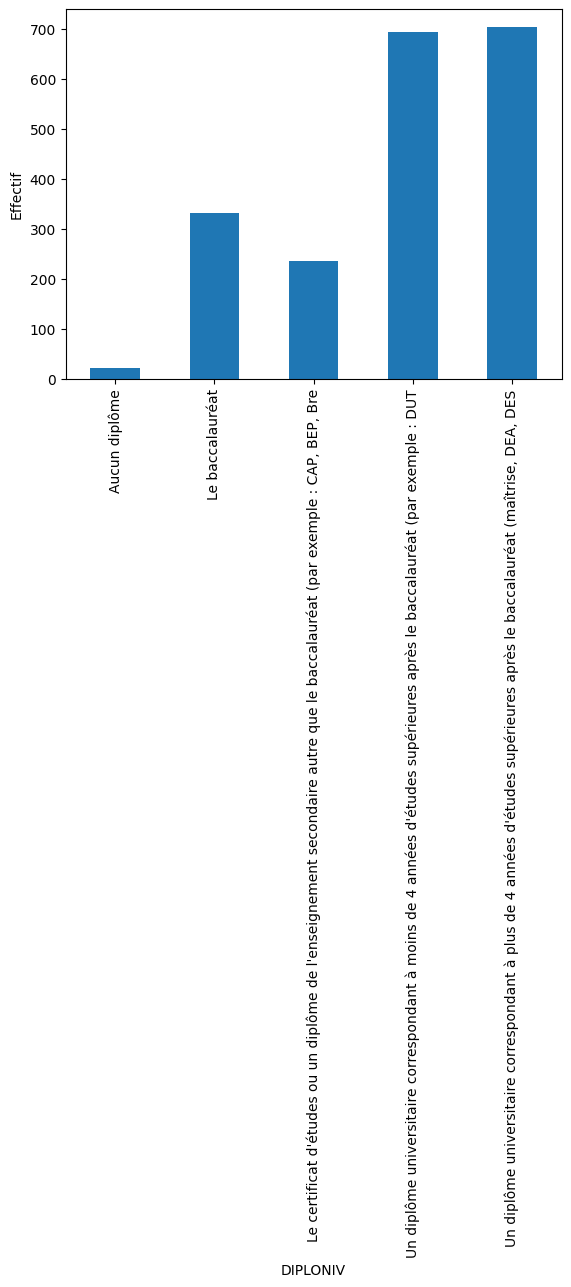

In [18]:
plt.figure()
df["DIPLONIV"].value_counts().sort_index().plot(kind='bar')
plt.ylabel("Effectif")
plt.show()

In [19]:
df["DIPLONIV"]=df["DIPLONIV"].replace({"Aucun diplôme": "Sans diplôme", "Le certificat d'études ou un diplôme de l'enseignement secondaire autre que le baccalauréat (par exemple : CAP, BEP, Bre": "CAP/BEP", "Le baccalauréat": "Bac", "Un diplôme universitaire correspondant à moins de 4 années d'études supérieures après le baccalauréat (par exemple : DUT": "Bac+2", "Un diplôme universitaire correspondant à plus de 4 années d'études supérieures après le baccalauréat (maîtrise, DEA, DES": "Bac+4 ou plus"}, inplace=True)

C:\Users\sylvain\AppData\Local\Temp\ipykernel_31076\724785370.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["DIPLONIV"]=df["DIPLONIV"].replace({"Aucun diplôme": "Sans diplôme", "Le certificat d'études ou un diplôme de l'enseignement secondaire autre que le baccalauréat (par exemple : CAP, BEP, Bre": "CAP/BEP", "Le baccalauré

In [20]:
df

,SEXE,AGE,SITCONJ,RESNB,RESISOL,LOGAUTRE,MASQUE,TEMPS,INQUIET,VOISINS,CONTROL,AMIS,FAMILLE,POL,DIPLONIV,SITPROF_rec,PCS_rec6,REV,POIDS_init
0,Une femme,30-39,Non,1,"Oui, autant que je voulais","Non, je suis toujours dans mon logement habituel.",Non sélectionné,"Non, je ne manque pas du tout de temps libre",Non sélectionné,Non sélectionné,"Non, jamais",Ni plus ni moins,Plus souvent,Je ne me retrouve pas dans ces catégories,Bac+4 ou plus,A la recherche d'un emploi,Cadres et professions intellectuelles supérieures,Moins de 800 euros par mois,0.234182
1,Une femme,30-39,Non,5,"Oui, mais pas autant que je voulais","Non, je suis toujours dans mon logement habituel.",Non sélectionné,"Oui, je manque un peu de temps libre",Oui,Oui,"Oui, une seule fois",Moins souvent,Plus souvent,Au centre,Bac+2,En études,Cadres et professions intellectuelles supérieures,Moins de 800 euros par mois,0.745062
2,Une femme,18-29,Non,2,"Oui, autant que je voulais","Non, je suis toujours dans mon logement habituel.",Oui,"Non, je ne manque pas vraiment de temps libre",Non sélectionné,Non sélectionné,"Non, jamais",Plus souvent,Ni plus ni moins,A gauche,Bac+4 ou plus,A la recherche d'un emploi,Cadres et professions intellectuelles supérieures,6000 euros par mois et plus,0.231059
3,Une femme,40-49,Oui,2,"Oui, autant que je voulais","Non, je suis toujours dans mon logement habituel.",Non sélectionné,"Non, je ne manque pas du tout de temps libre",Non sélectionné,Non sélectionné,"Non, jamais",Plus souvent,Plus souvent,A gauche,Bac+2,En emploi,Professions intermédiaires,De 5000 euros à moins de 6000 euros par mois,0.562083
4,Une femme,50-59,Non,1,"Oui, autant que je voulais","Non, je suis toujours dans mon logement habituel.",Non sélectionné,"Non, je ne manque pas vraiment de temps libre",Non sélectionné,Non sélectionné,"Non, jamais",Ni plus ni moins,Ni plus ni moins,Ni à gauche ni à droite,Bac+4 ou plus,En emploi,Cadres et professions intellectuelles supérieures,De 3000 euros à moins de 4000 euros par mois,0.206142
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,Un homme,60-69,Oui,2,"Oui, autant que je voulais","Non, je suis toujours dans mon logement habituel.",Non sélectionné,"Oui, je manque vraiment de temps libre",Oui,Non sélectionné,"Non, jamais",Ni plus ni moins,Ni plus ni moins,A droite,CAP/BEP,Retraité(e),Cadres et professions intellectuelles supérieures,De 1200 euros à moins de 1600 euros par mois,1.760163
1996,Une femme,18-29,Oui,2,"Oui, autant que je voulais","Non, je suis toujours dans mon logement habituel.",Non sélectionné,"Non, je ne manque pas du tout de temps libre",Oui,Non sélectionné,"Non, jamais",Moins souvent,Moins souvent,A gauche,Bac+4 ou plus,En emploi,Professions intermédiaires,De 2000 euros à moins de 2500 euros par mois,0.782869
1997,Un homme,60-69,Oui,2,"Oui, autant que je voulais","Non, je suis toujours dans mon logement habituel.",Oui,"Non, je ne manque pas du tout de temps libre",Oui,Oui,"Non, jamais",Moins souvent,Moins souvent,Je ne me retrouve pas dans ces catégories,Bac,En emploi,Professions intermédiaires,De 3000 euros à moins de 4000 euros par mois,1.126863
1998,Une femme,40-49,Oui,3,"Oui, autant que je voulais","Non, je suis toujours dans mon logement habituel.",Oui,"Non, je ne manque pas vraiment de temps libre",Oui,Non sélectionné,"Non, jamais",Ni plus ni moins,Ni plus ni moins,Ni à gauche ni à droite,Bac+2,En emploi,Professions intermédiaires,De 4000 euros à moins de 5000 euros par mois,0.562083


In [21]:
df["DIPLONIV"].value_counts()

DIPLONIV
Bac+4 ou plus    704
Bac+2            694
Bac              332
CAP/BEP          236
Sans diplôme      23
Name: count, dtype: int64

In [22]:
df["REV"]=df["REV"].replace({"Moins de 800 euros par mois":"-800€","De 800 euros à moins de 1200 euros par mois": "800€ à 1200€","De 1200 euros à moins de 1600 euros par mois":"1200€ à 1600€", "De 1600 euros à moins de 2000 euros par mois":"1600€ à 2000€", "De 2000 euros à moins de 2500 euros par mois":"2000€ à 2500€", "De 2500 euros à moins de 3000 euros par mois":"2500€ à 3000€", "De 3000 euros à moins de 4000 euros par mois":"3000€ à 4000€", "De 4000 euros à moins de 5000 euros par mois":"4000€ à 5000€", "De 5000 euros à moins de 6000 euros par mois":"5000€ à 6000€", "6000 euros par mois et plus":"6000€ et plus"}, inplace=True)

C:\Users\sylvain\AppData\Local\Temp\ipykernel_31076\3203882333.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["REV"]=df["REV"].replace({"Moins de 800 euros par mois":"-800€","De 800 euros à moins de 1200 euros par mois": "800€ à 1200€","De 1200 euros à moins de 1600 euros par mois":"1200€ à 1600€", "De 1600 euros à moins de 2

In [23]:
df["REV"].value_counts()

REV
3000€ à 4000€    396
2500€ à 3000€    256
4000€ à 5000€    251
2000€ à 2500€    242
1600€ à 2000€    192
1200€ à 1600€    162
5000€ à 6000€    151
6000€ et plus    128
800€ à 1200€     110
-800€             77
Name: count, dtype: int64

# Analyse univariée

Nous allons étudier tout d'abord l'ensemble des variables pour ce qu'elles sont, en faisant une analyse univariée pour chacune d'entre elles.

In [24]:
df["POIDS_init"].describe()

count    2000.000000
mean        0.995351
std         0.881778
min         0.188401
25%         0.356939
50%         0.695011
75%         1.321763
max         6.033236
Name: POIDS_init, dtype: float64

In [25]:
# Comme la variable "POIDS_init" est une variable continue, on peut la transformer en variable catégorielle en utilisant des intervalles de poids. Par exemple, on peut créer des catégories telles que "Poids léger", "Poids moyen" et "Poids lourd" en fonction des valeurs de poids.
df["POIDS_init"] = pd.cut(df["POIDS_init"], bins=[0, 0.4, 0.8, np.inf], labels=["Poids léger", "Poids moyen", "Poids lourd"])

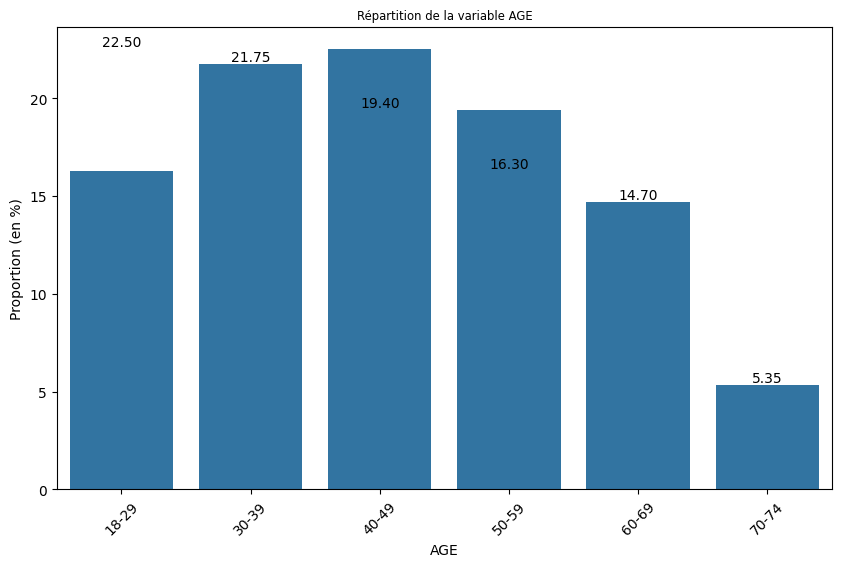

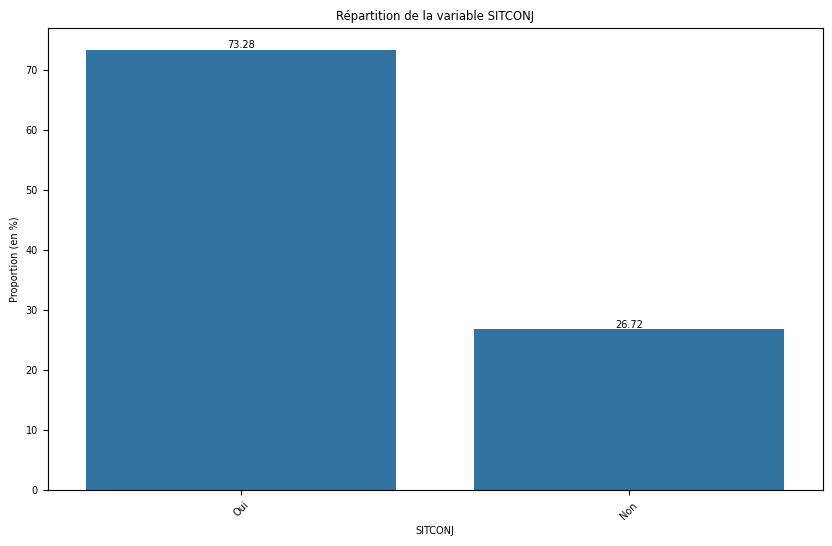

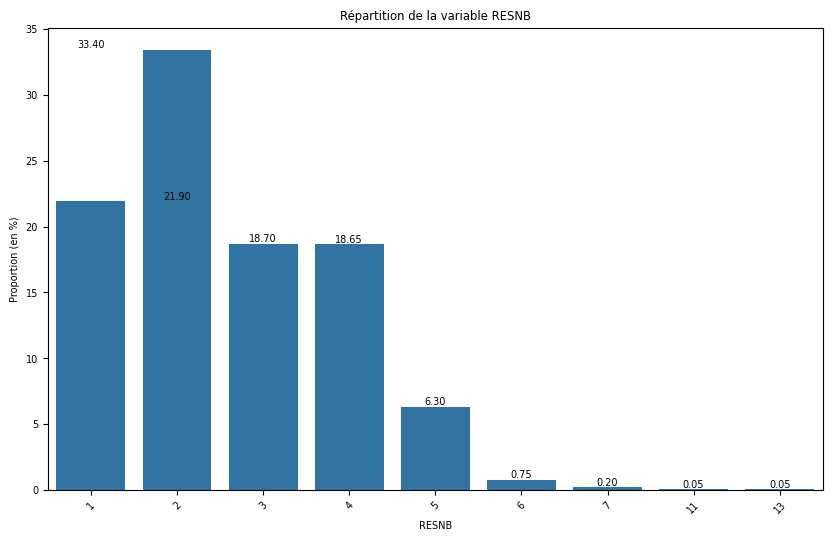

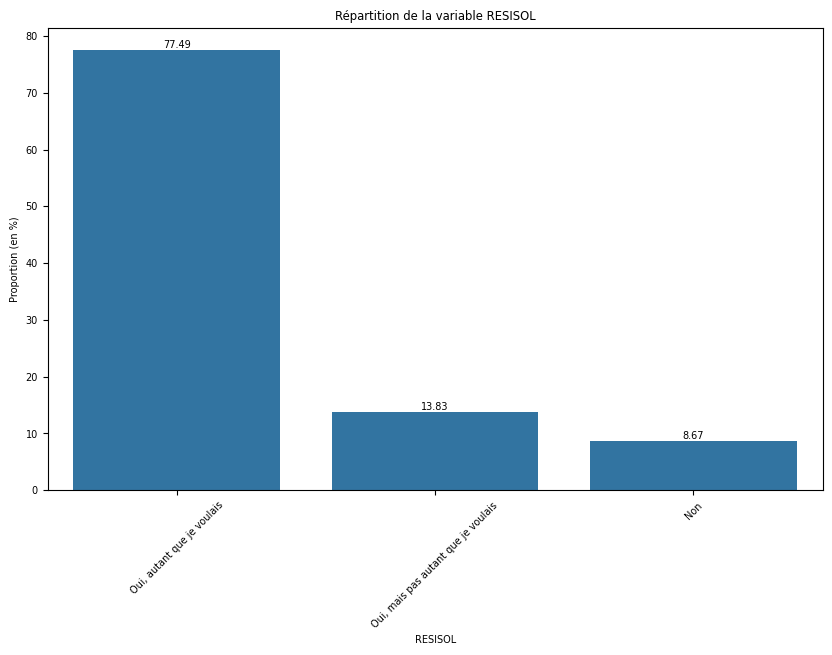

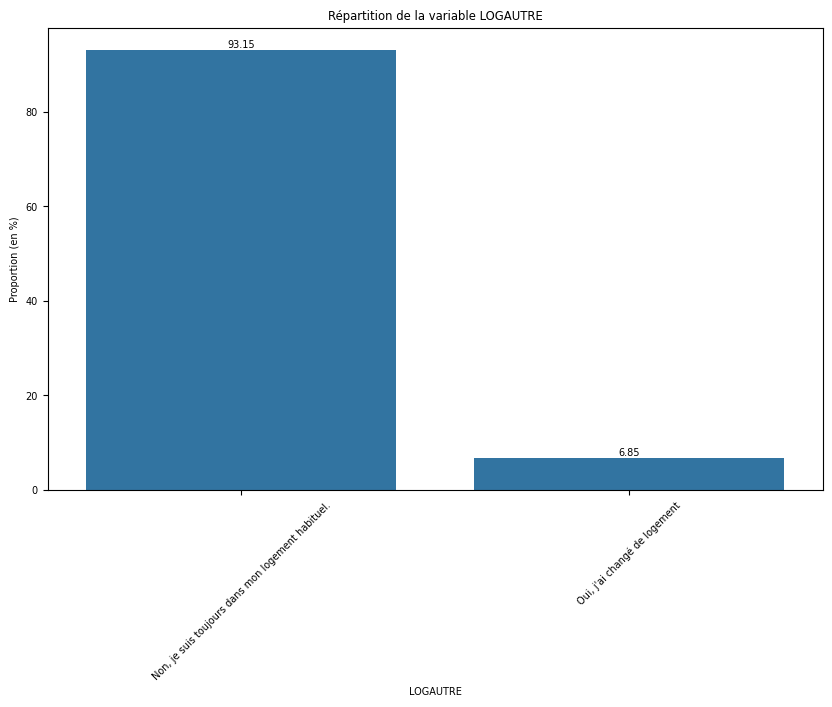

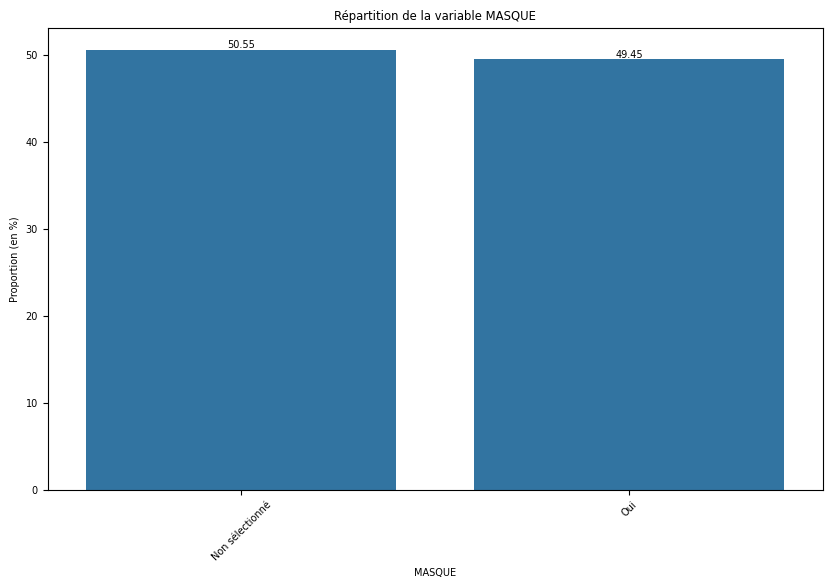

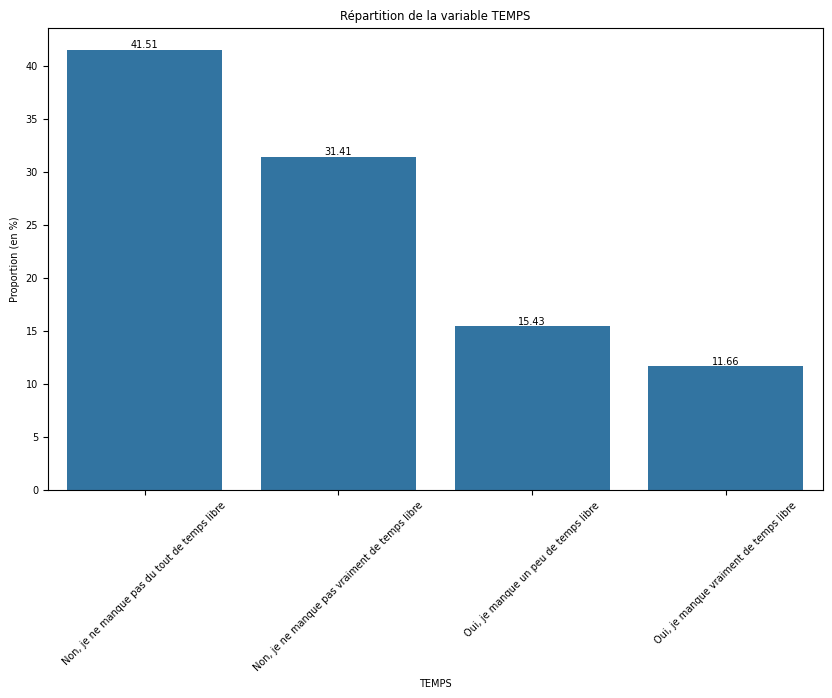

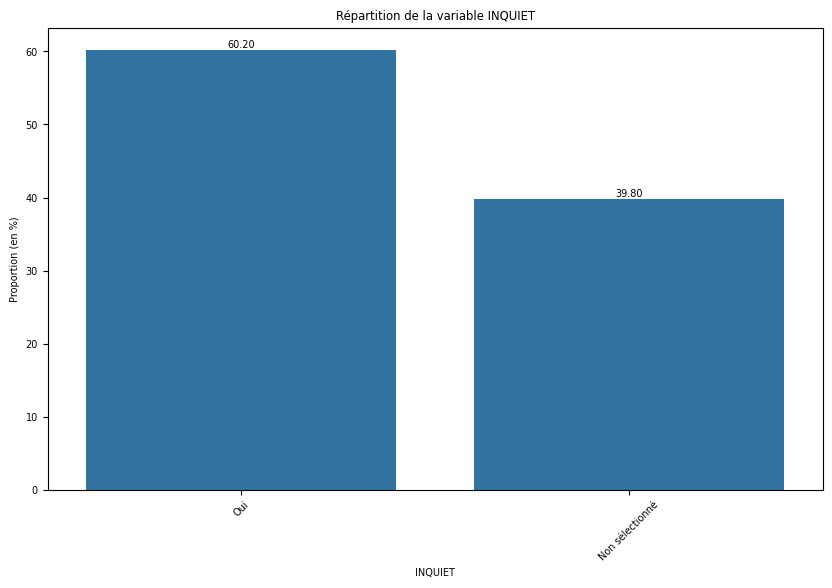

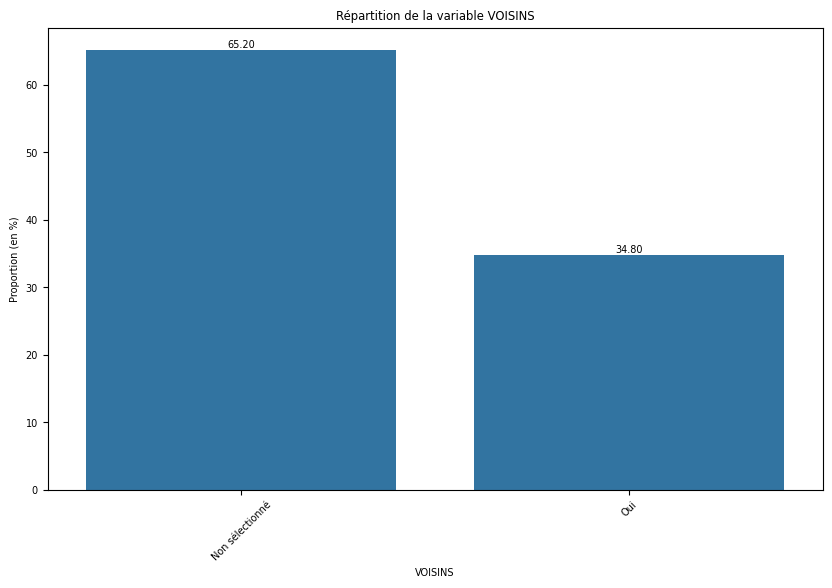

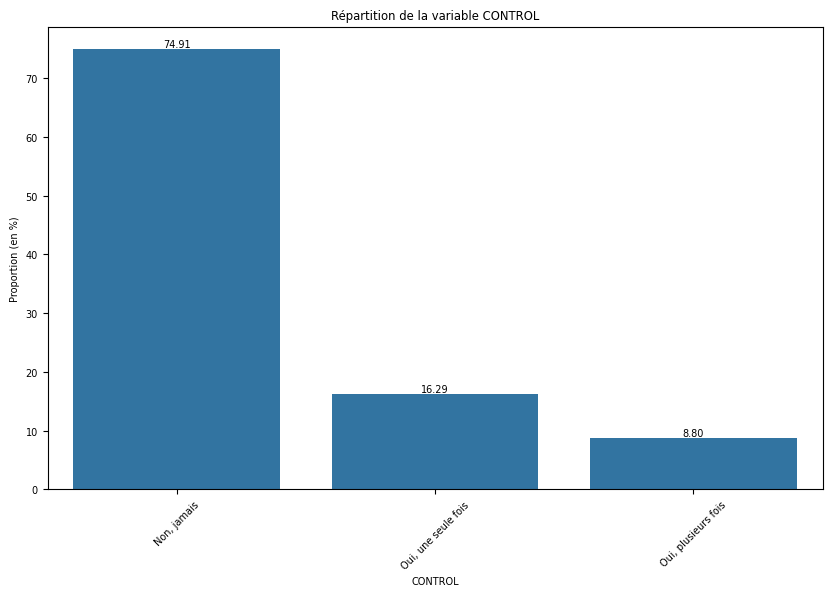

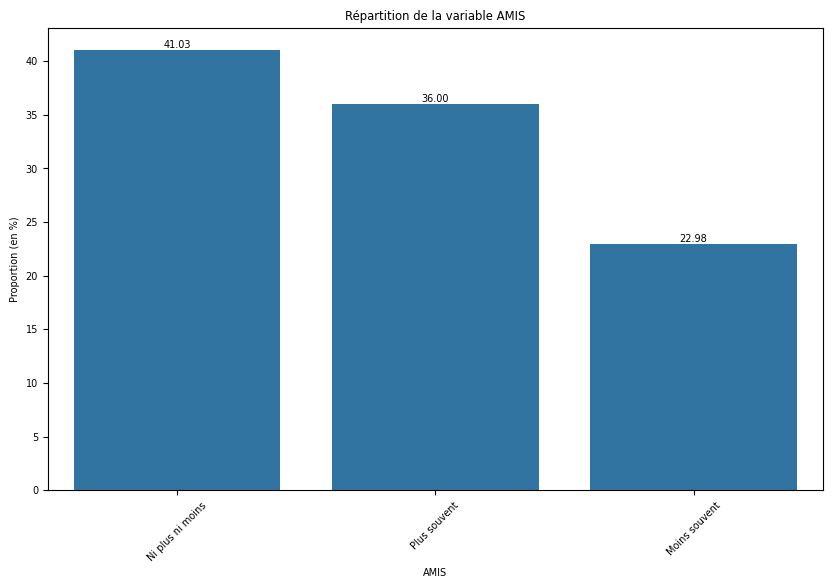

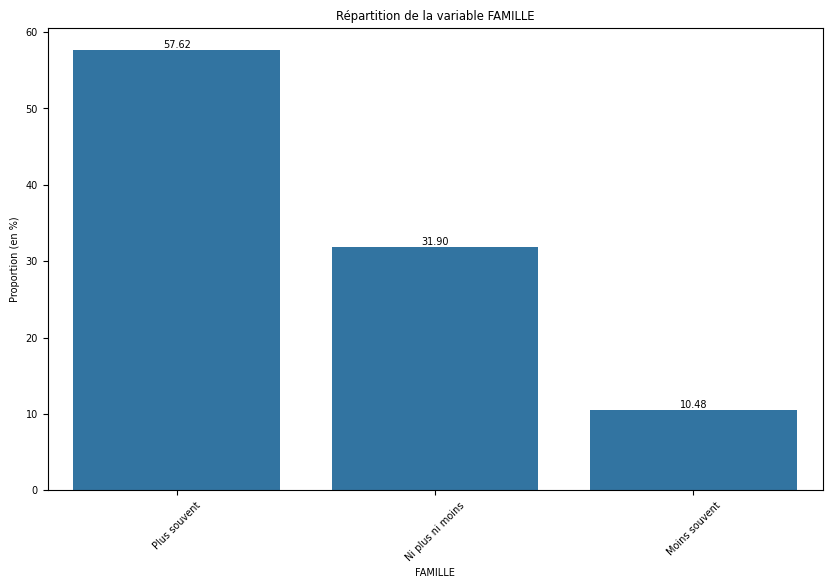

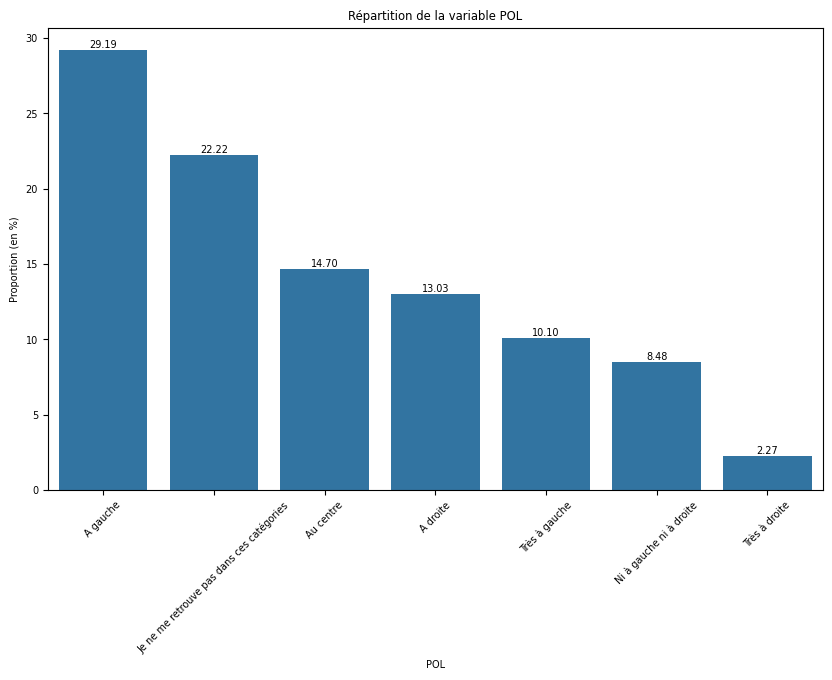

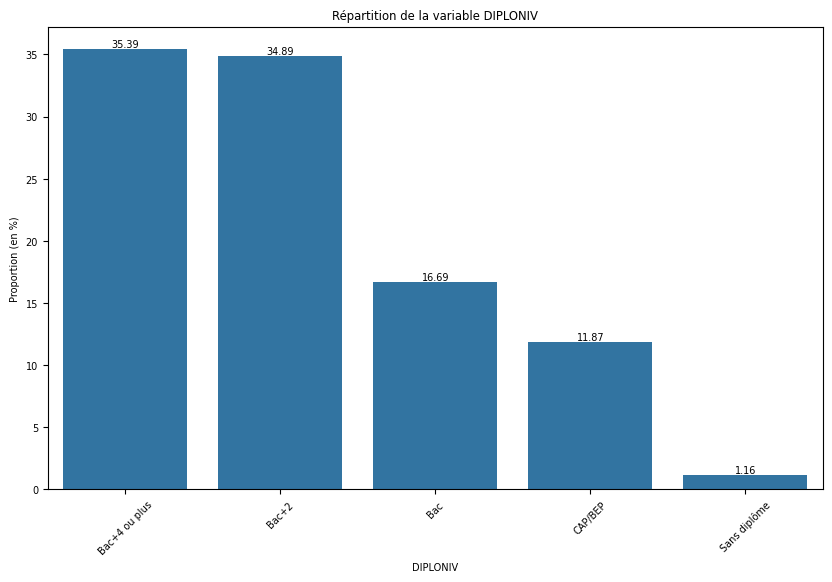

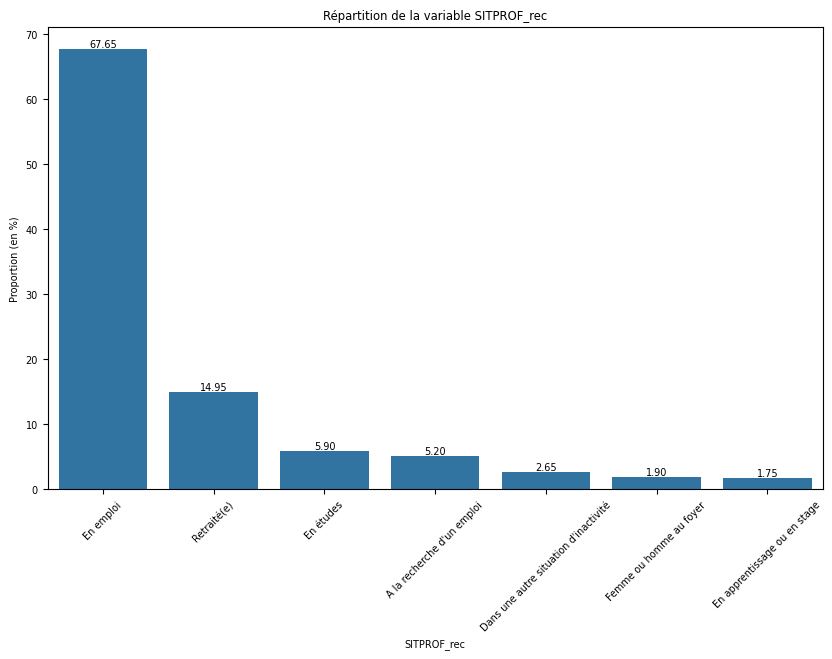

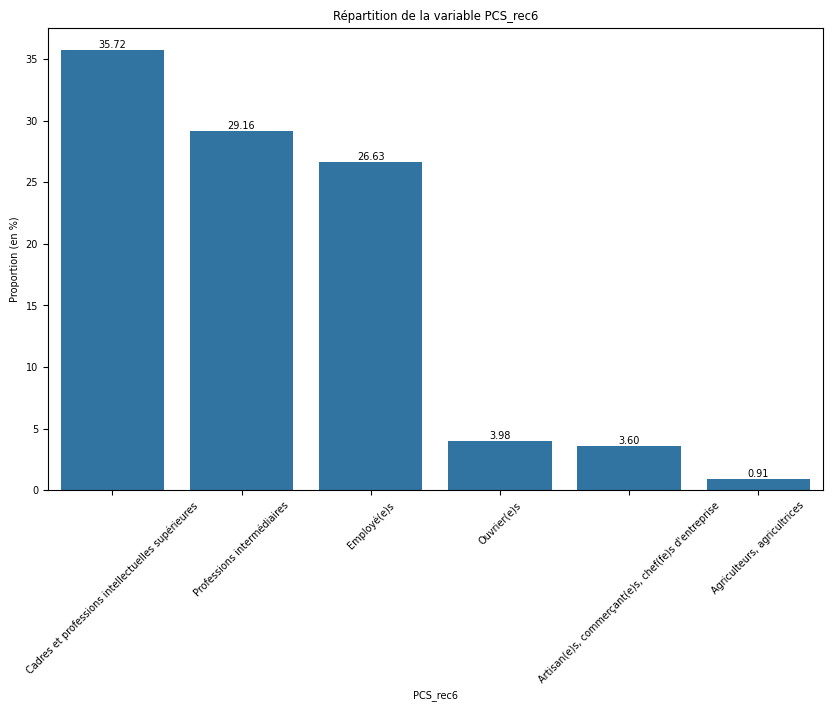

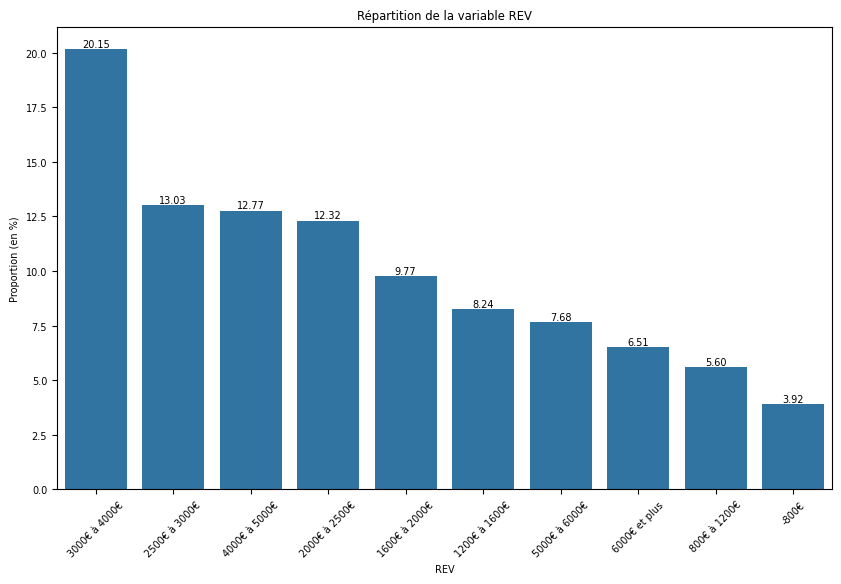

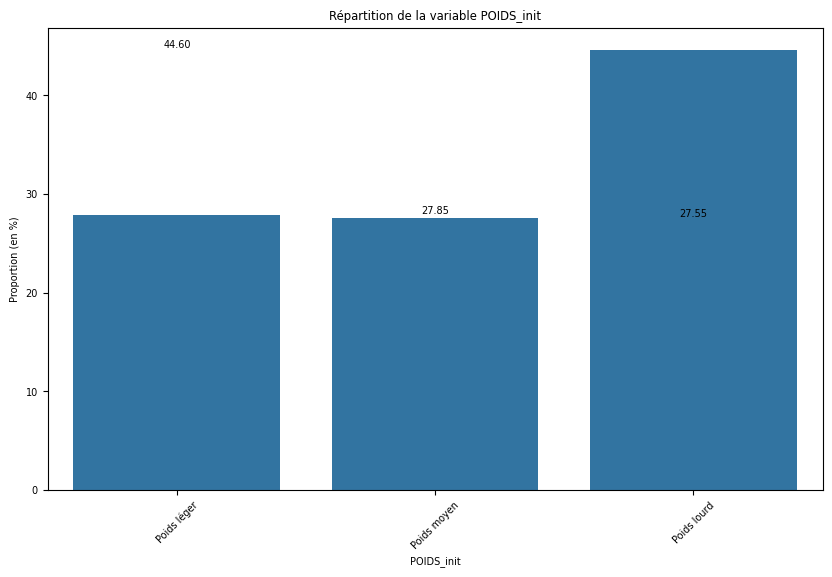

In [26]:
for column in df.columns[1:]:
    prop = df[column].value_counts(normalize=True) * 100
    plt.figure(figsize=(10, 6))
    sns.barplot(x=prop.index, y=prop.values)

    #Astuce pour ajouter les valeurs sur les barres
    for i, prop in enumerate(prop.values):
        plt.text(i, prop, f'{prop:.2f}', ha='center', va='bottom')

    #Titres d'axes et de graphique
    plt.ylabel("Proportion (en %)")
    plt.xlabel
    plt.xticks(rotation = 45)
    plt.rcParams.update({'font.size': 7})
    plt.title(f"Répartition de la variable {column}")
    plt.show()

### Analyse bivariée

De la même façon il est possible d'automatiquement la production de graphiques d'une analyse bivariée sur l'ensemble des variables. Pour ce faire, nous allons imbriquée une boucle dans autre boucle afin de croiser chacune des variables les unes avec les d'autres.

On peut représenter cela sous forme de tableaux croisées

In [27]:
for col1 in df.columns[0:4]:
    for col2 in df.columns[0:4]:
        if col1 != col2: #Ne pas croiser une colonne à elle-même
            # Grouper les données par les deux colonnes, compter le nb d'occurence (size)
            prop = df.groupby([col1, col2]).size()
            # Réinitialise l'index et donne un nom à la colonne des comptages d'occurrence
            prop = prop.reset_index(name="Count")
            # Ajoute une colonne proportion qui est égale au nb d'occurence 
            # divisé par la somme de la colonne des nb d'occurence x100
            prop["Proportion"] = prop["Count"]/prop.groupby(col1)["Count"].transform("sum") * 100

            print(prop)


         SEXE    AGE  Count  Proportion
0    Un homme  18-29     72   13.382900
1    Un homme  30-39     93   17.286245
2    Un homme  40-49    100   18.587361
3    Un homme  50-59    119   22.118959
4    Un homme  60-69    107   19.888476
5    Un homme  70-74     47    8.736059
6   Une femme  18-29    254   17.373461
7   Une femme  30-39    342   23.392613
8   Une femme  40-49    350   23.939808
9   Une femme  50-59    269   18.399453
10  Une femme  60-69    187   12.790698
11  Une femme  70-74     60    4.103967
        SEXE SITCONJ  Count  Proportion
0   Un homme     Non    146   27.238806
1   Un homme     Oui    390   72.761194
2  Une femme     Non    387   26.525017
3  Une femme     Oui   1072   73.474983
         SEXE  RESNB  Count  Proportion
0    Un homme      1    125   23.234201
1    Un homme      2    199   36.988848
2    Un homme      3     92   17.100372
3    Un homme      4     92   17.100372
4    Un homme      5     25    4.646840
5    Un homme      6      2    0.371747


Puis faire la même chose avec des graphiques :

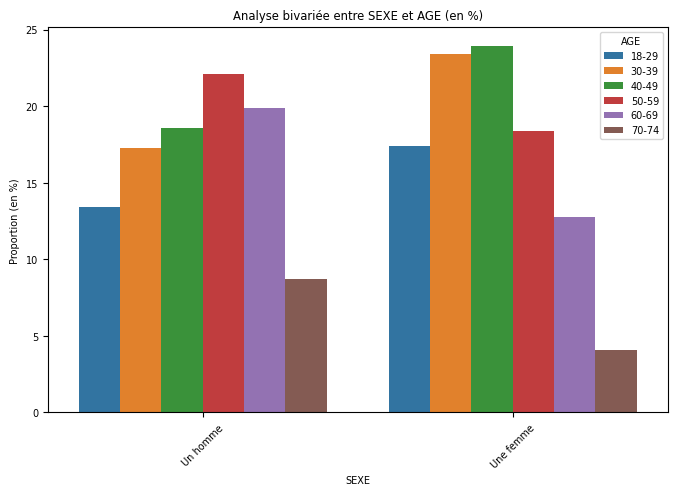

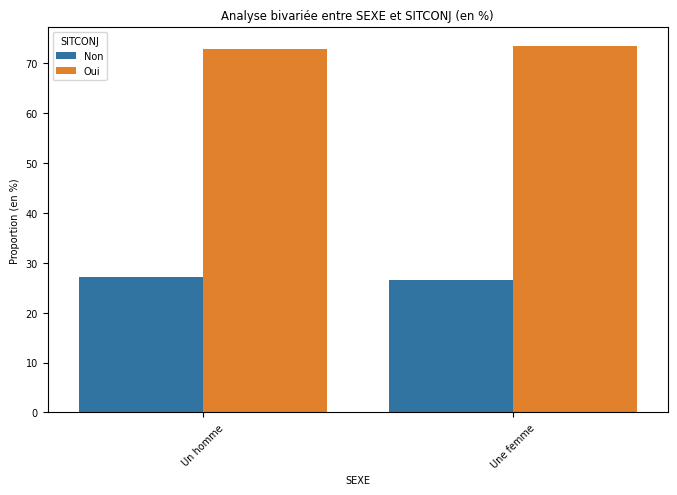

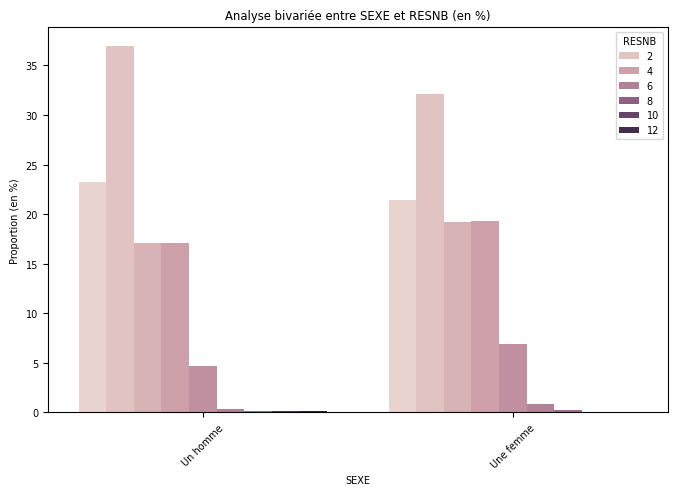

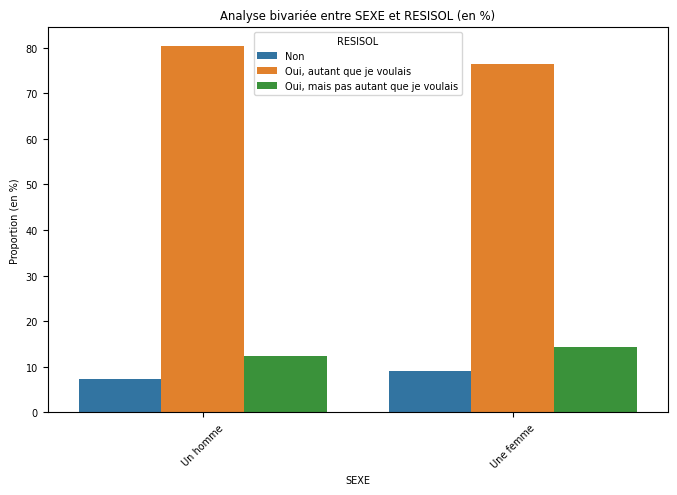

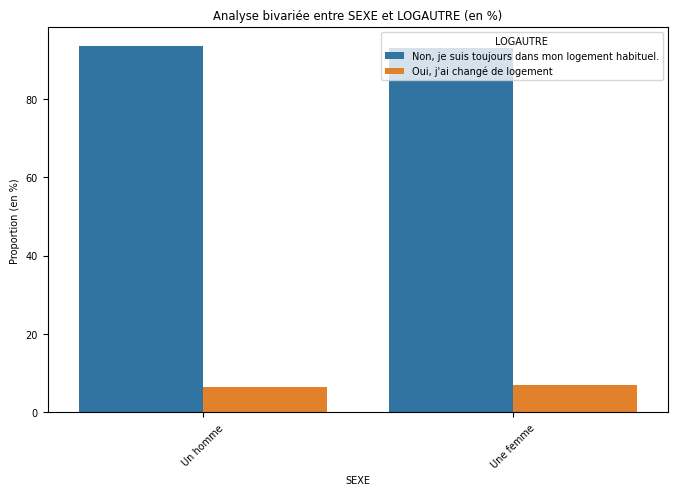

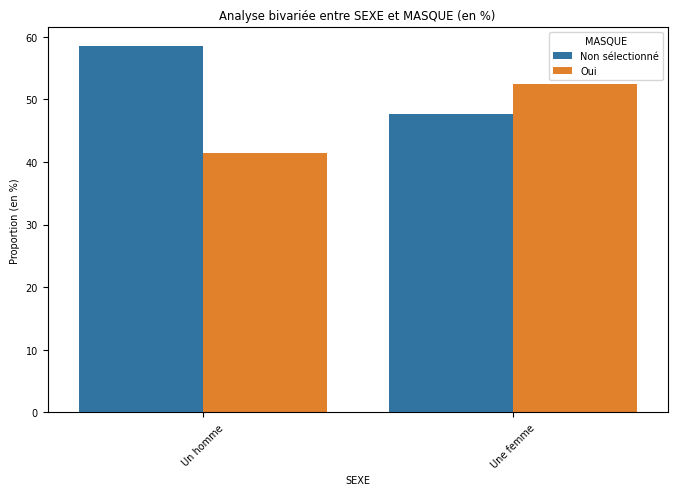

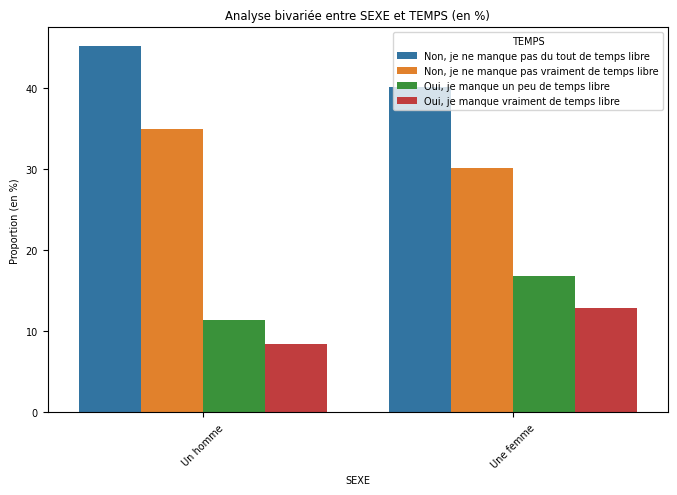

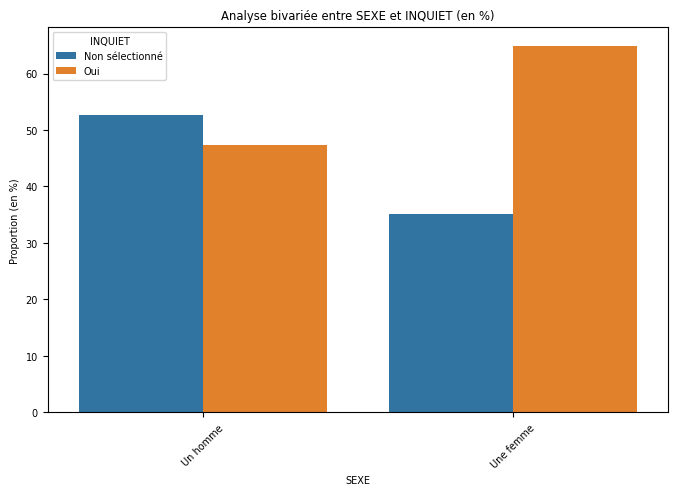

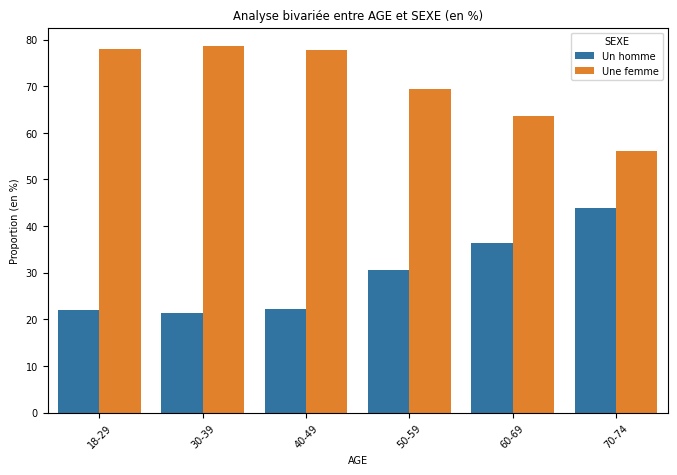

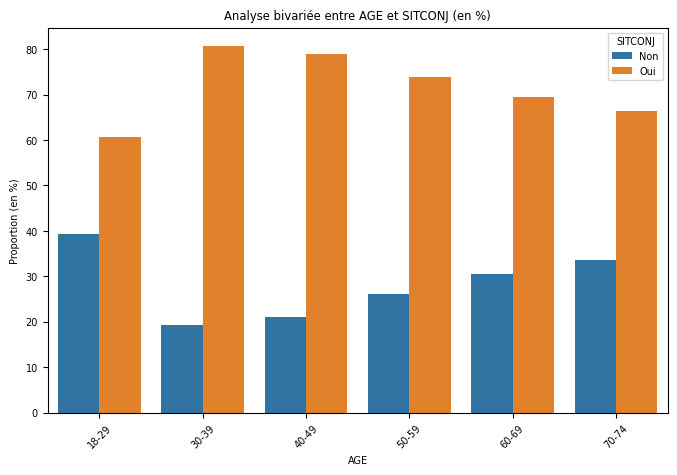

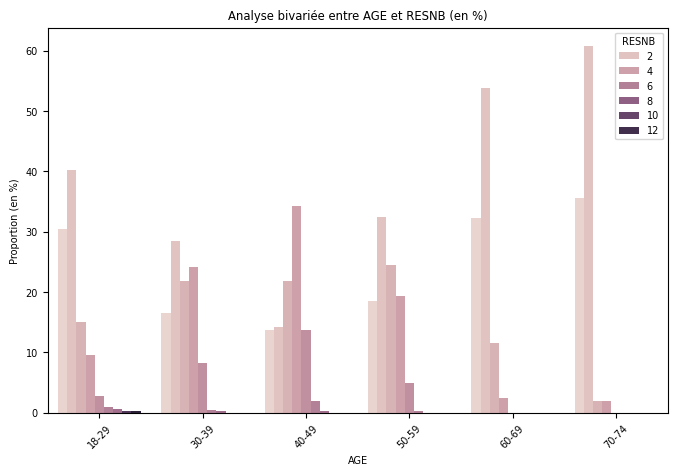

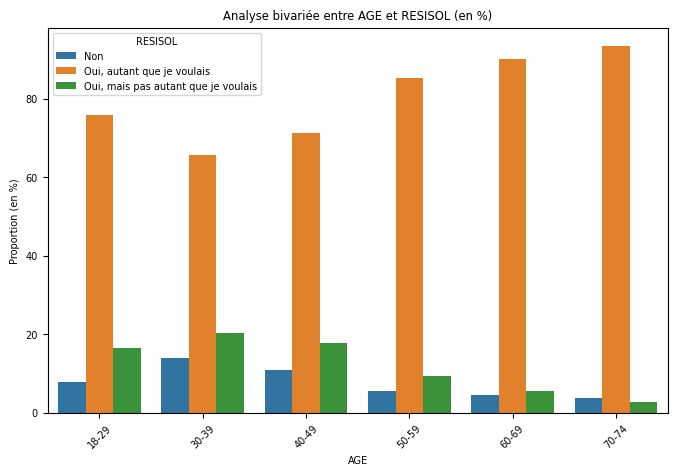

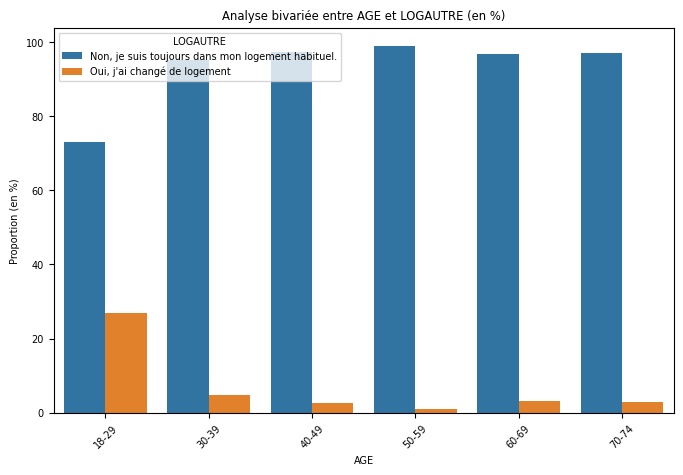

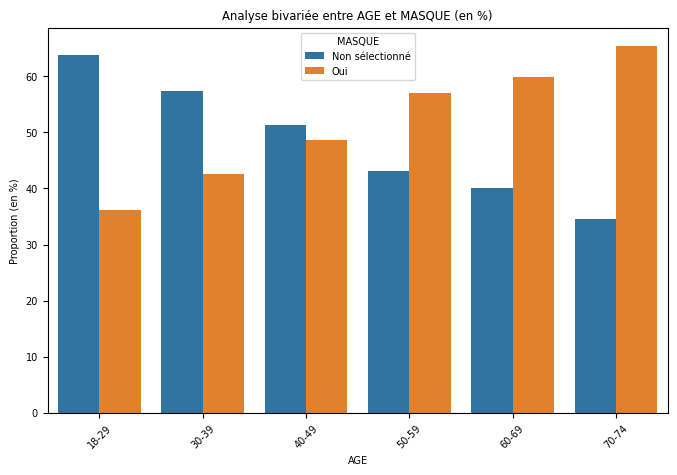

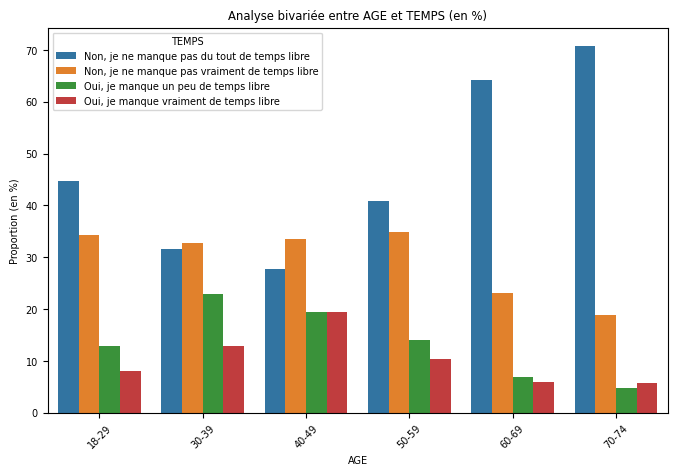

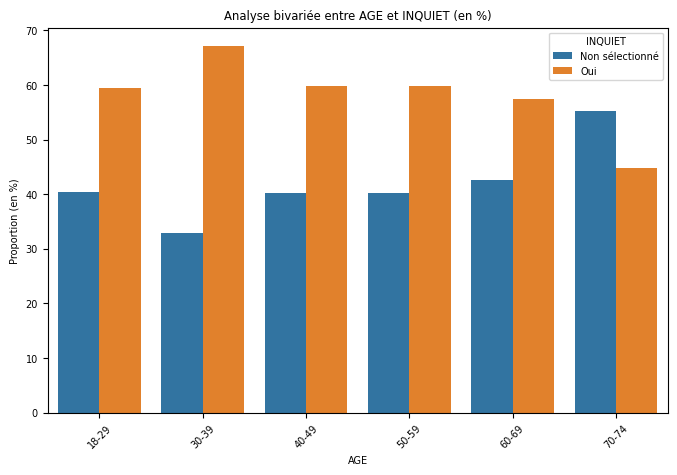

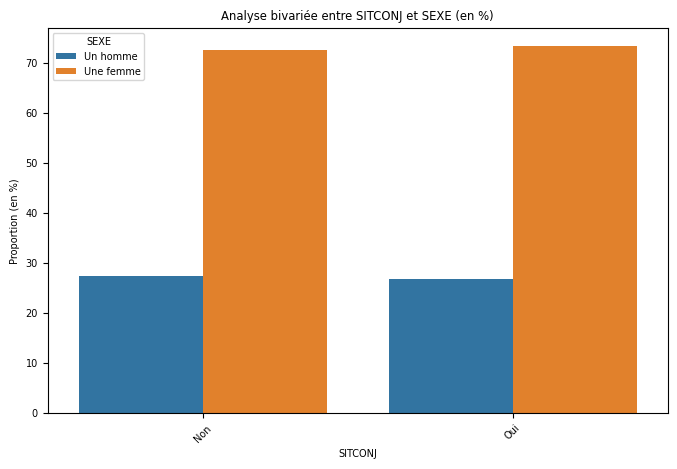

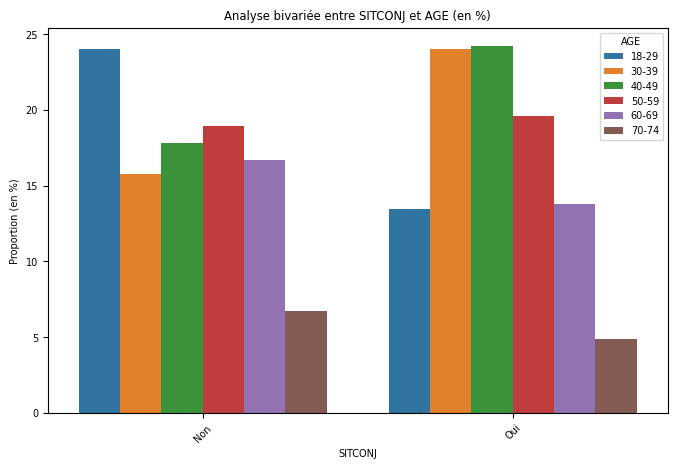

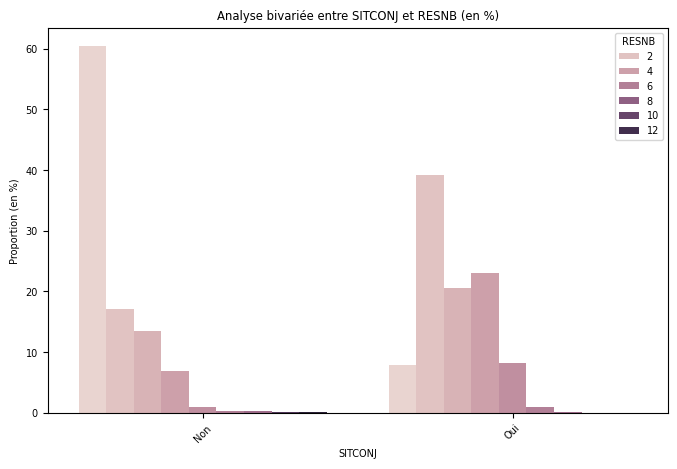

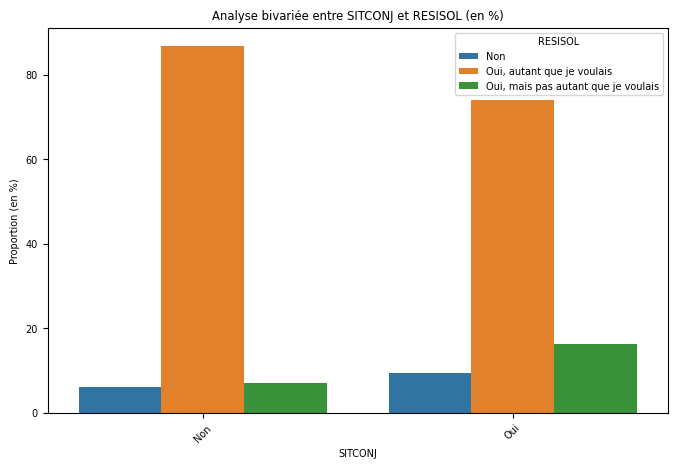

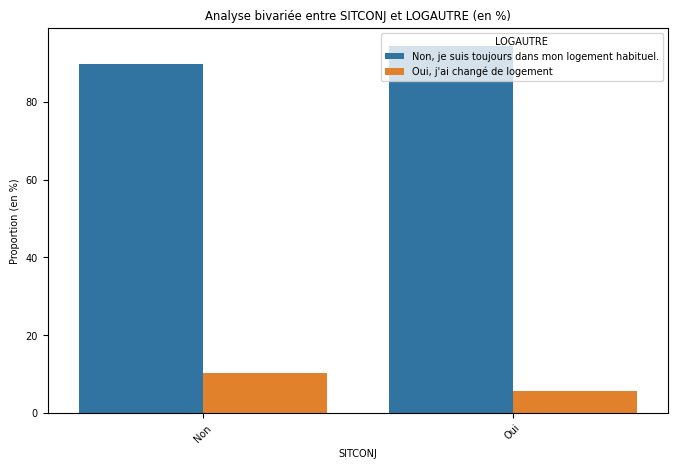

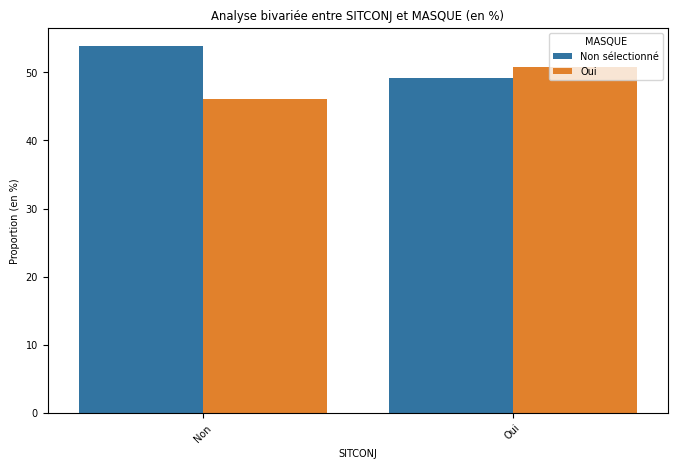

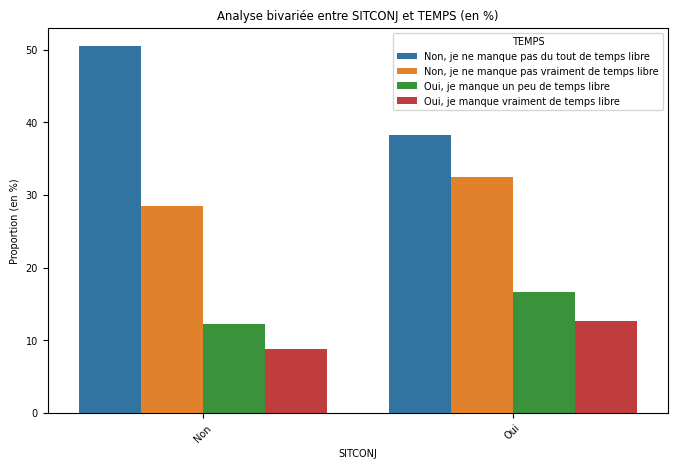

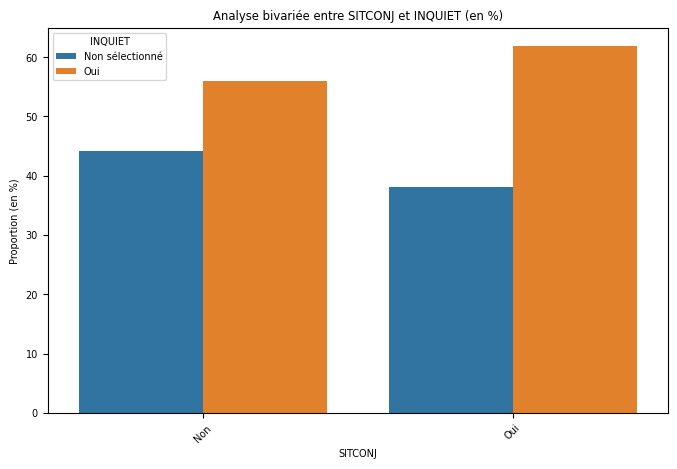

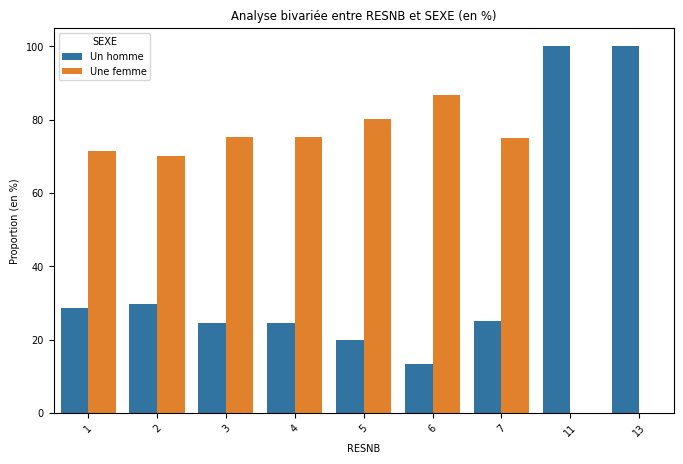

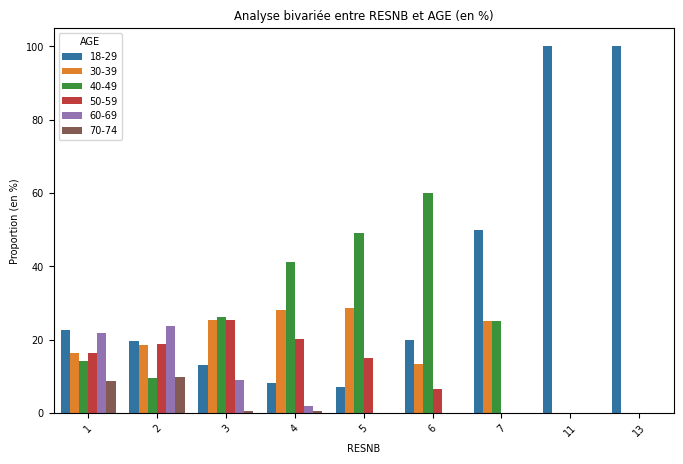

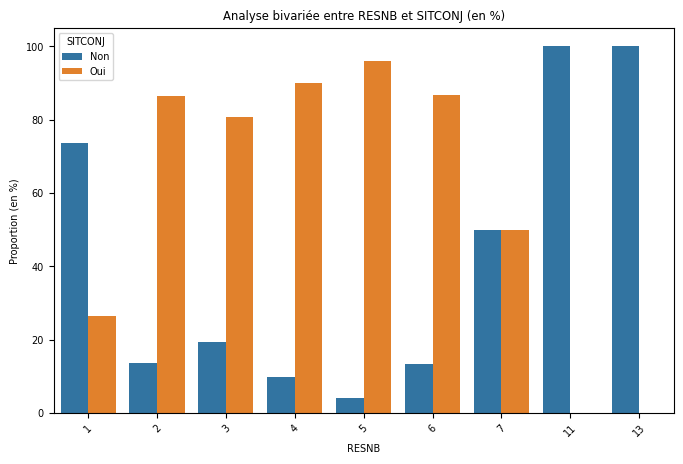

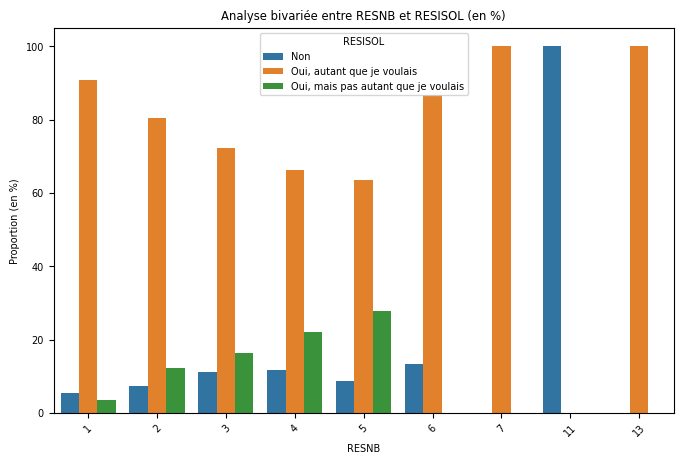

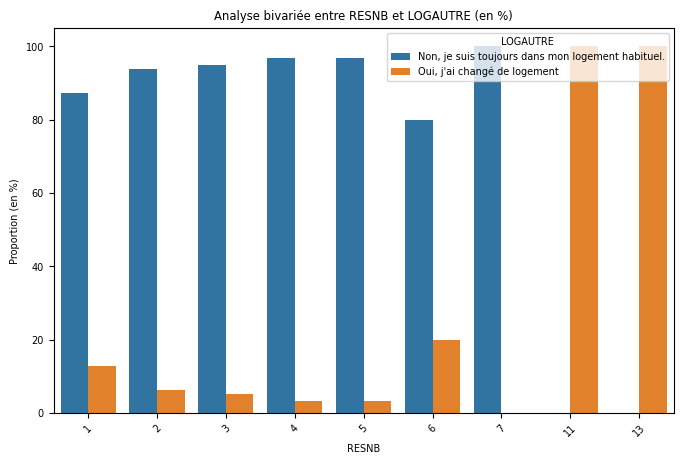

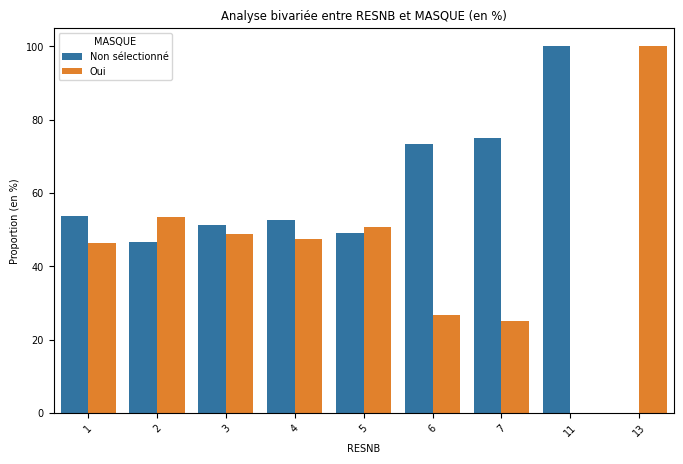

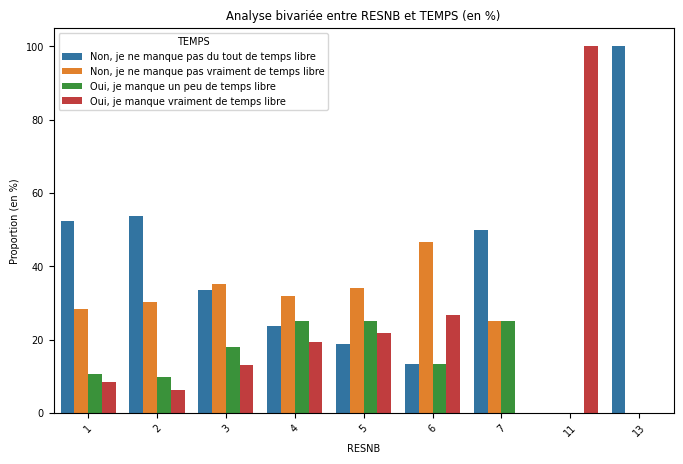

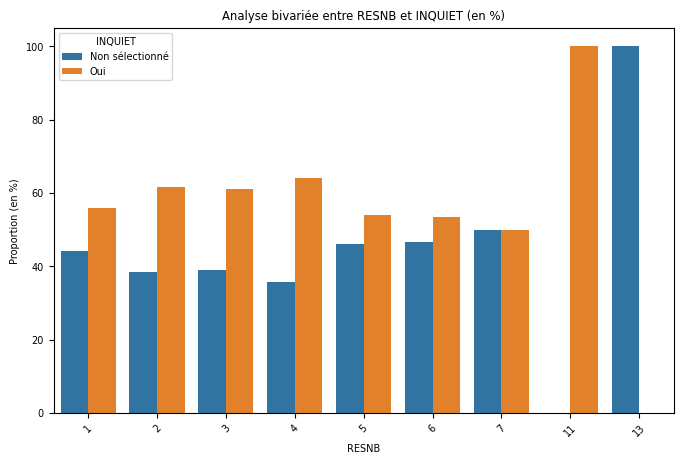

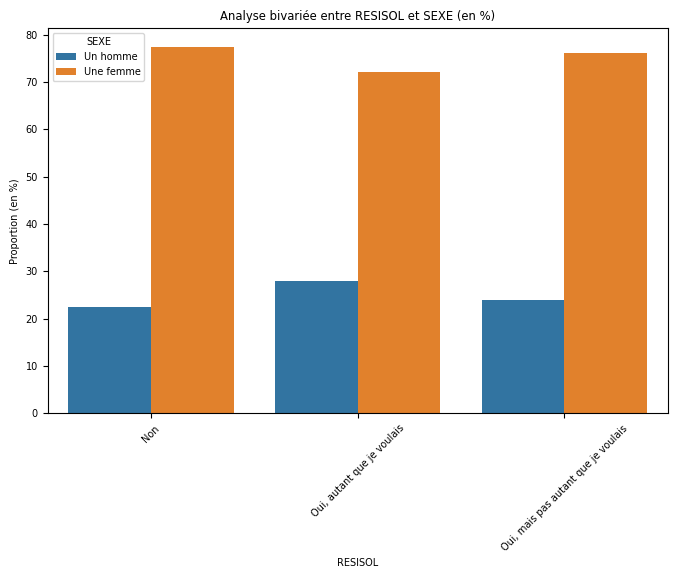

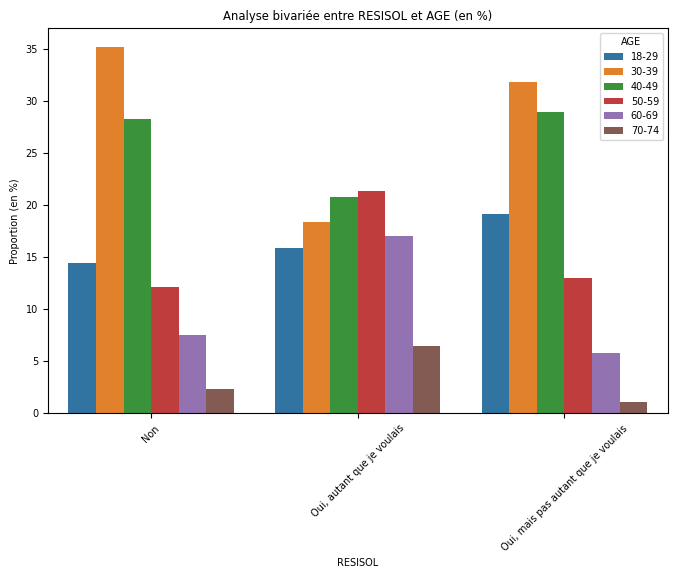

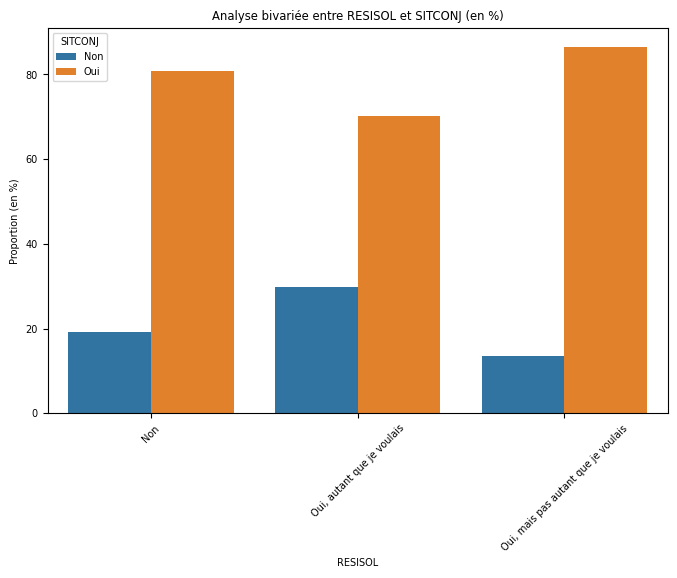

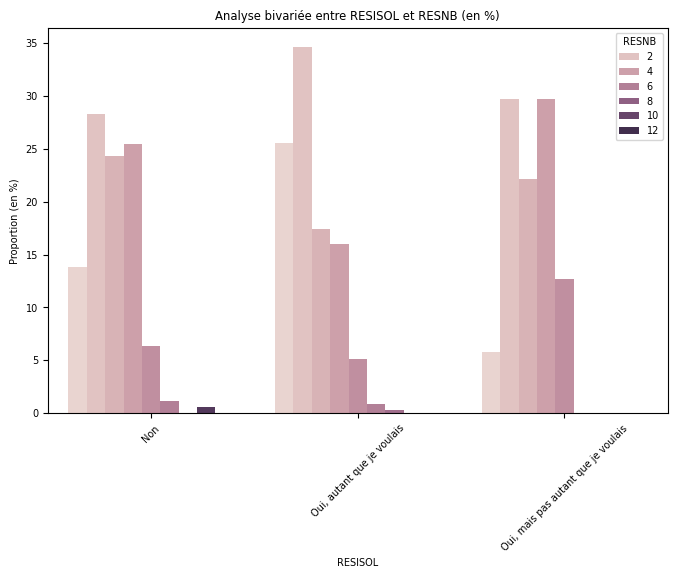

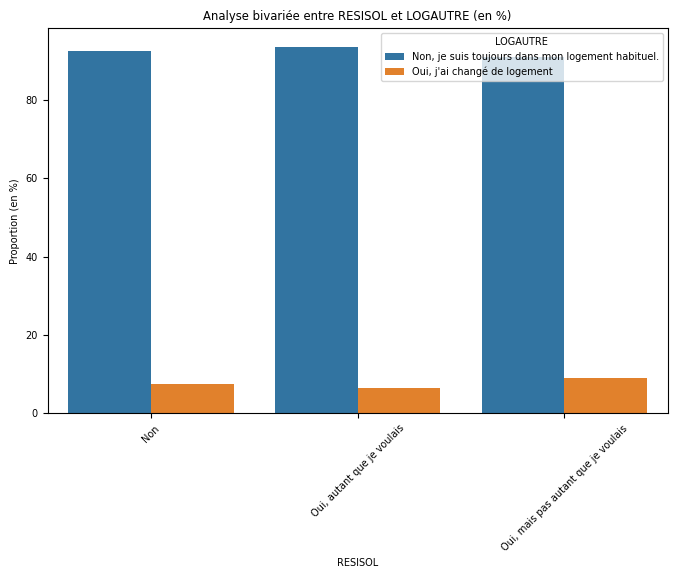

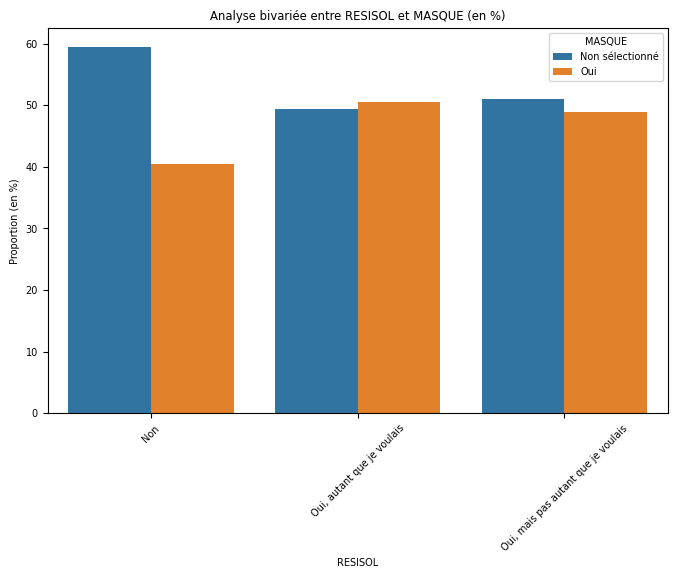

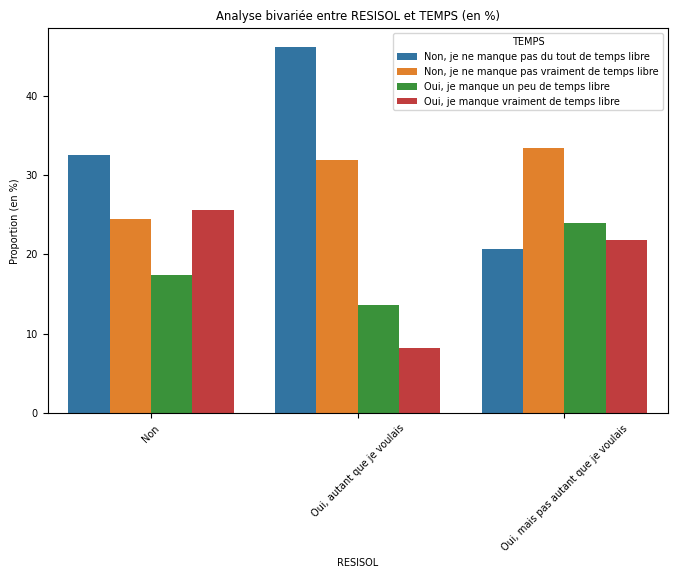

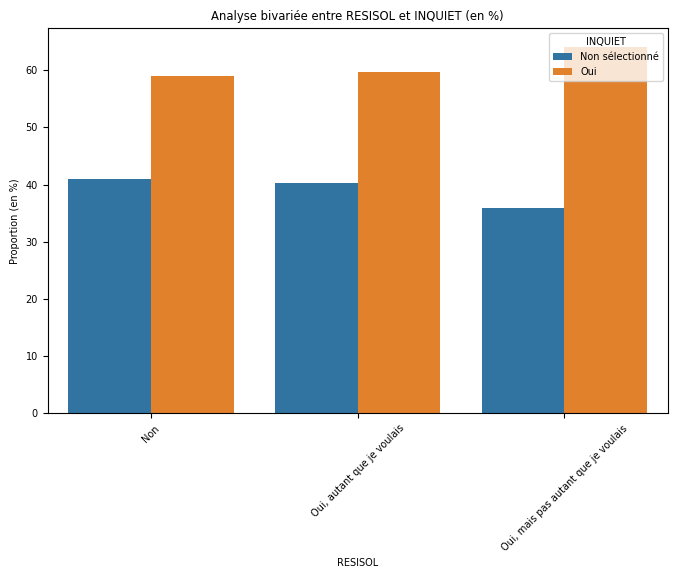

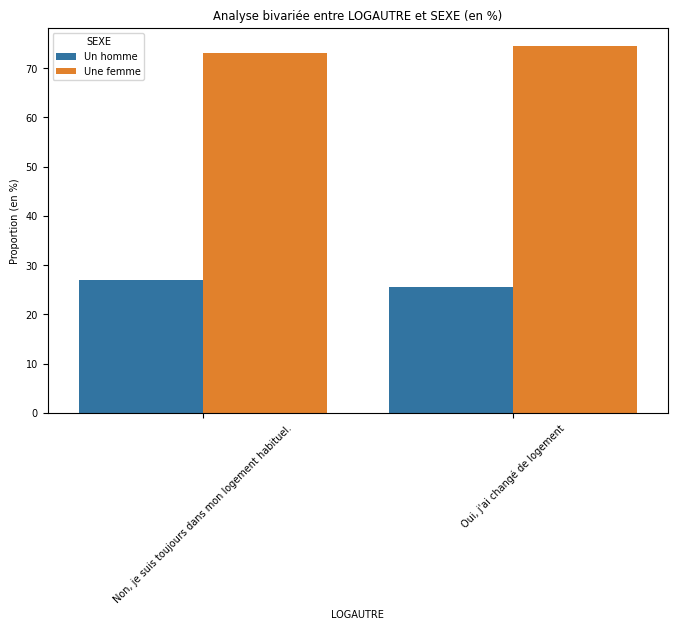

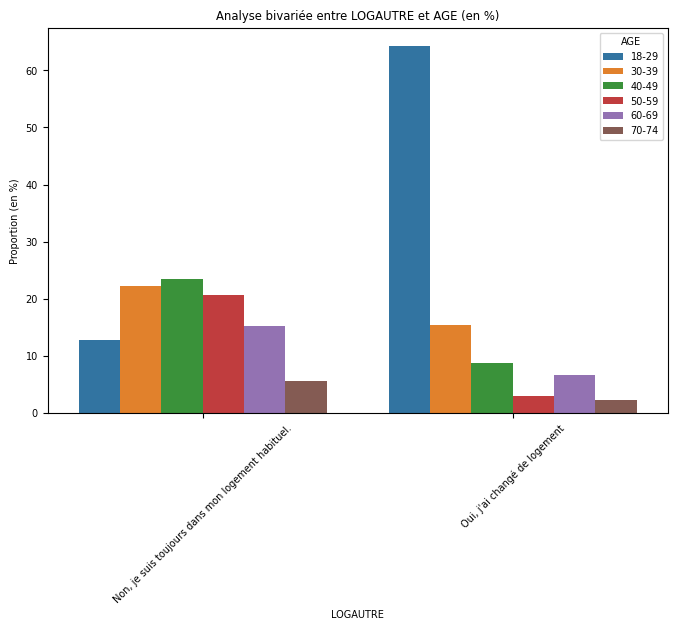

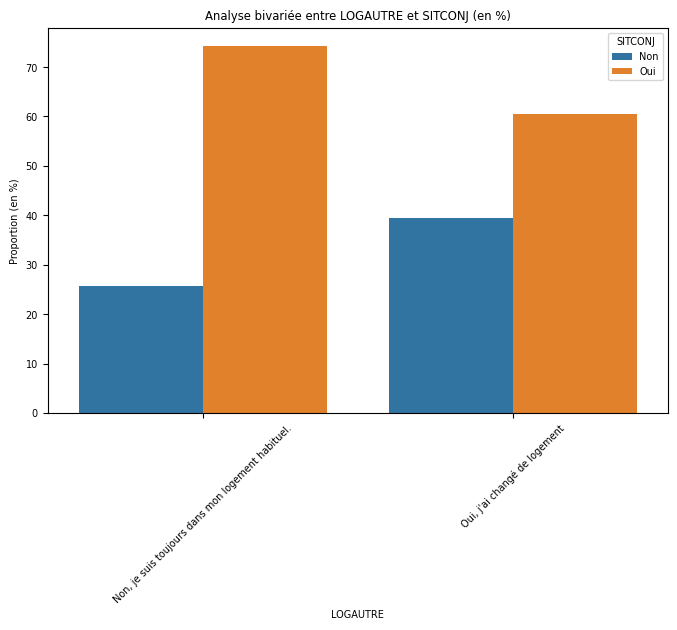

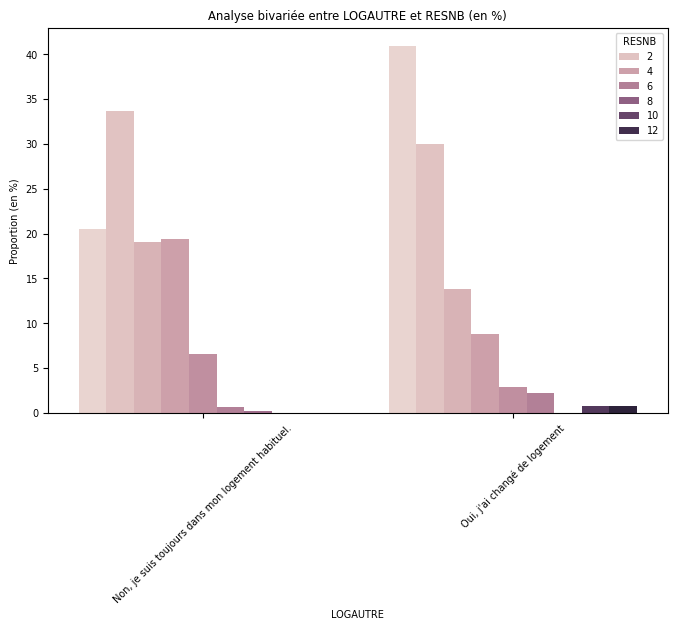

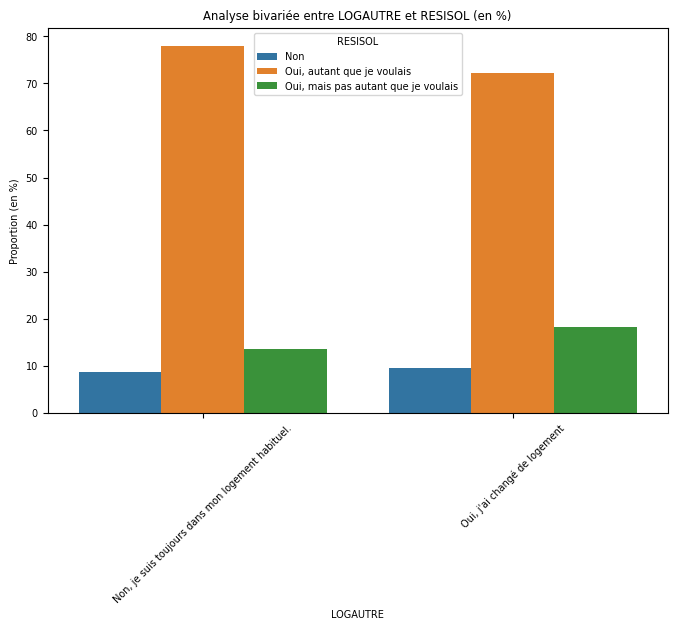

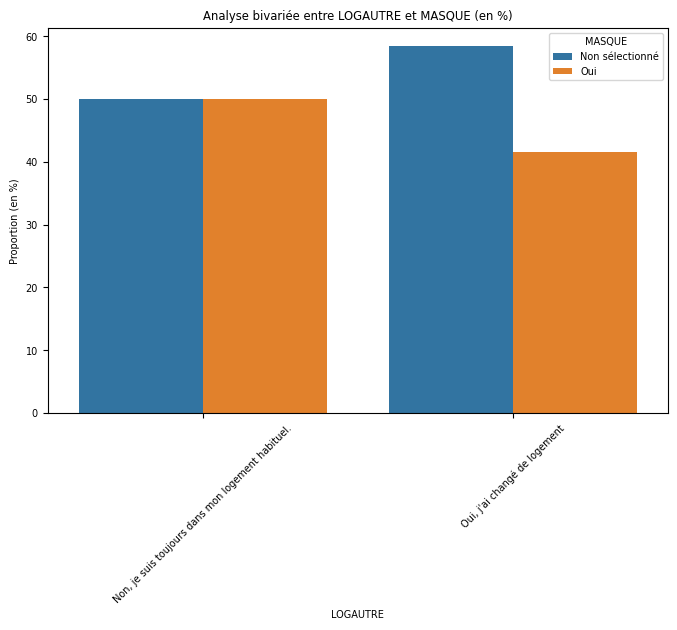

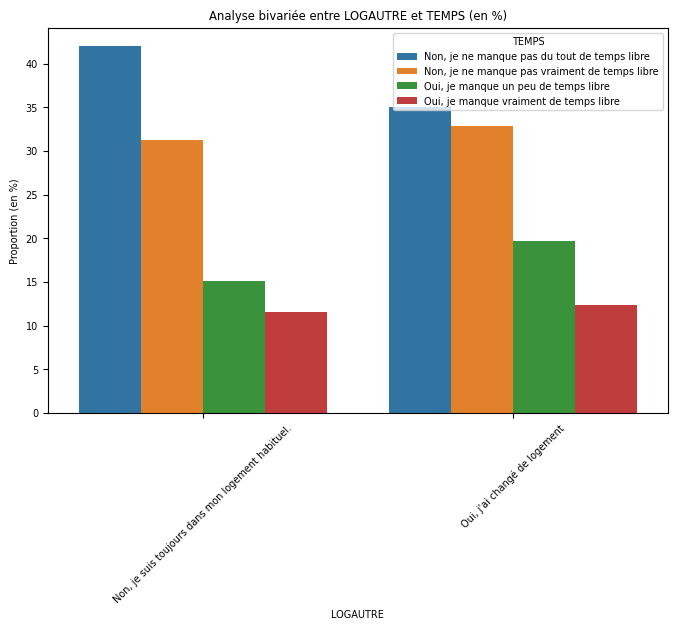

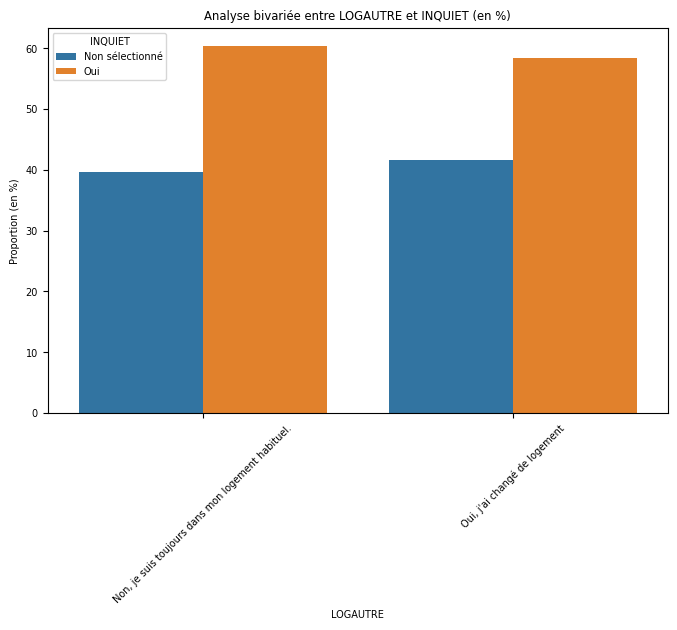

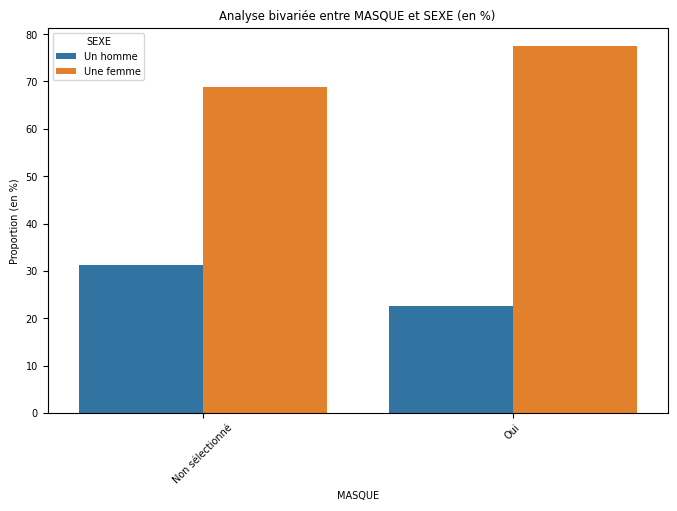

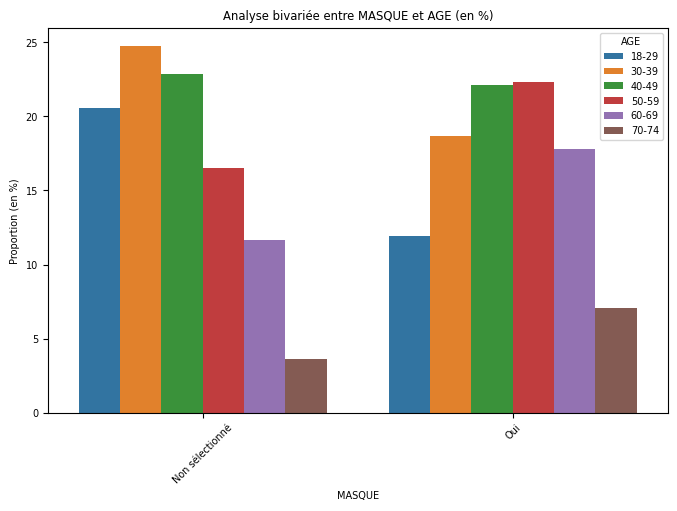

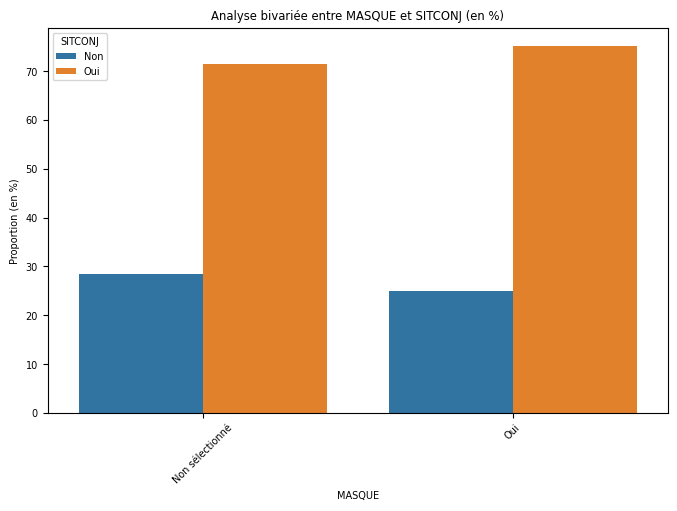

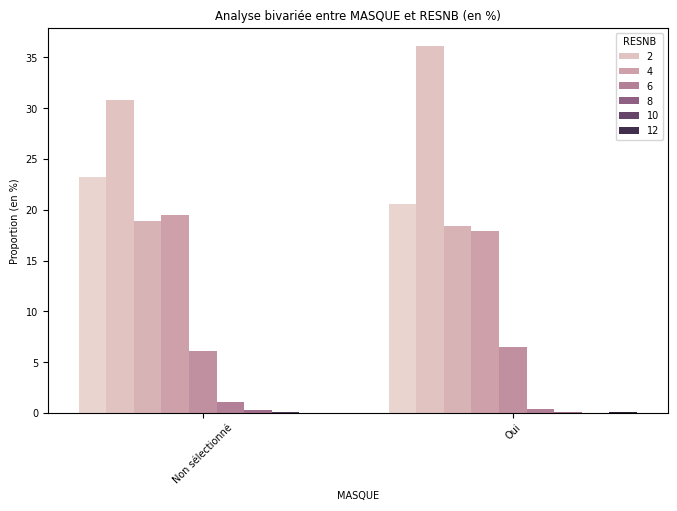

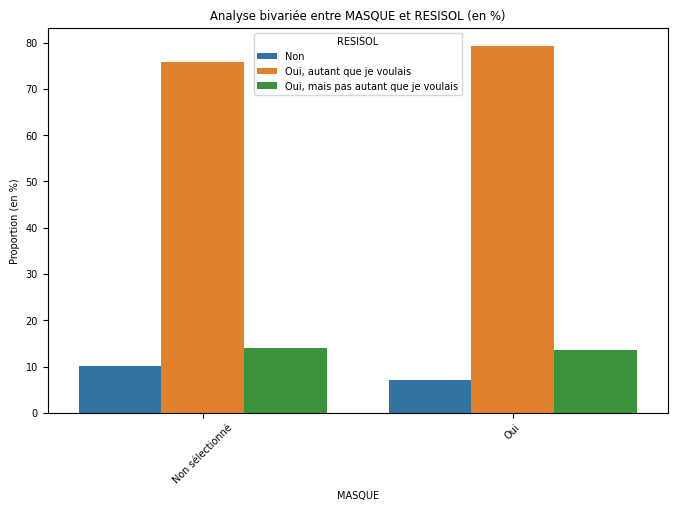

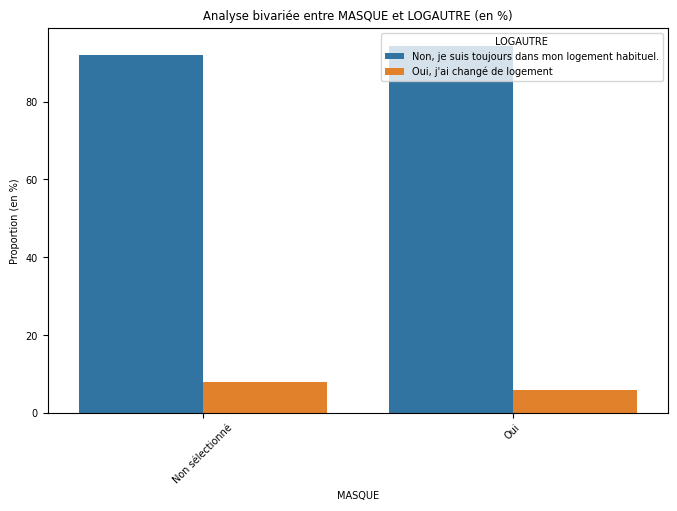

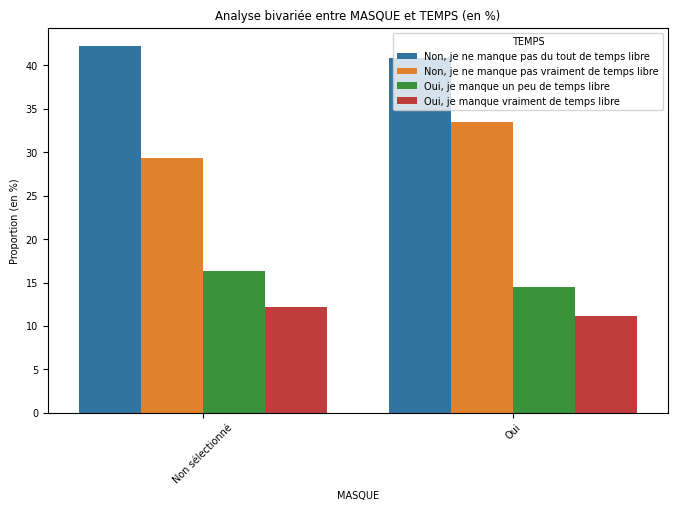

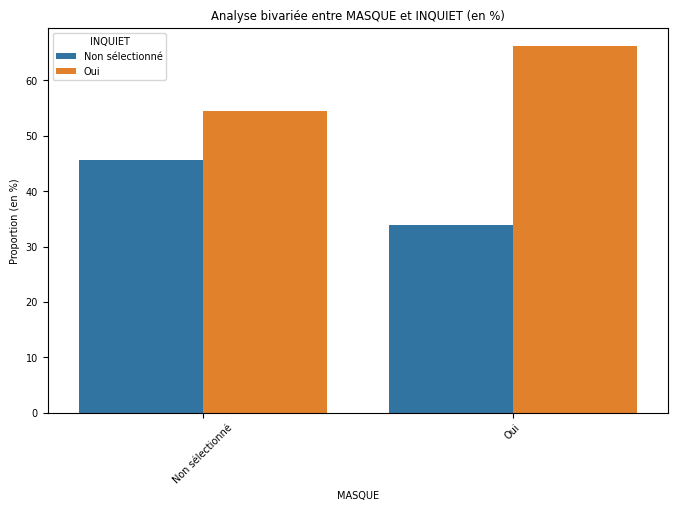

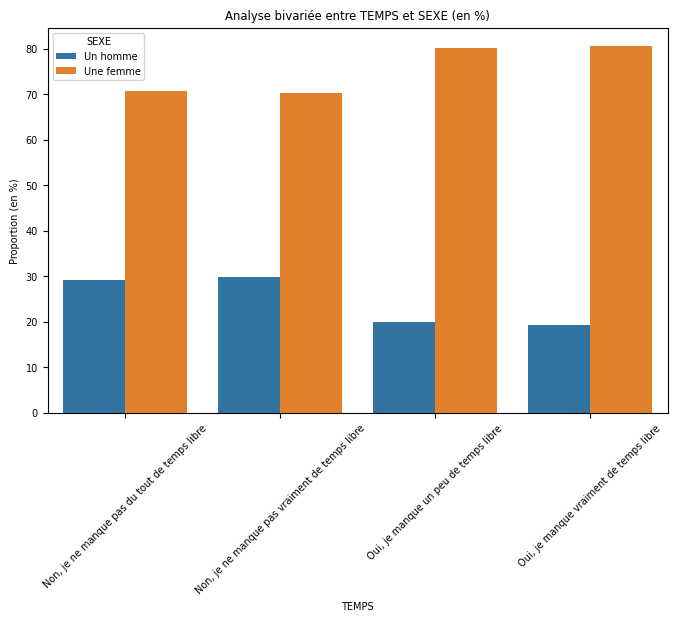

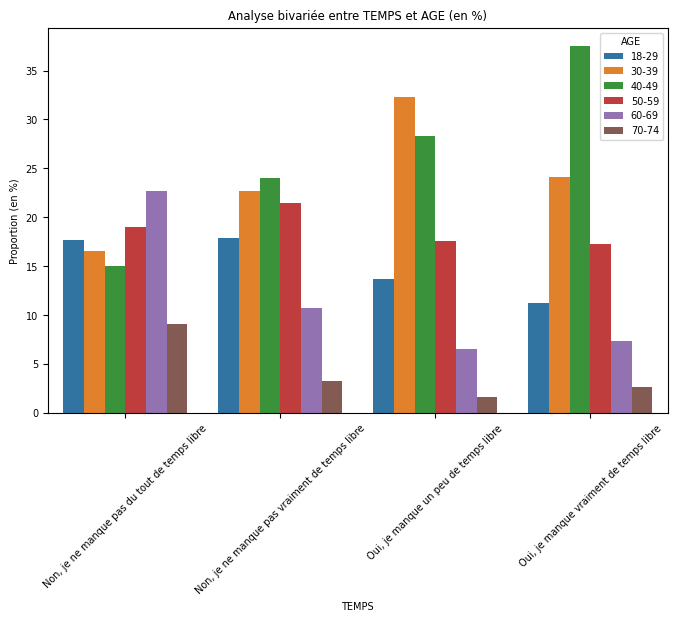

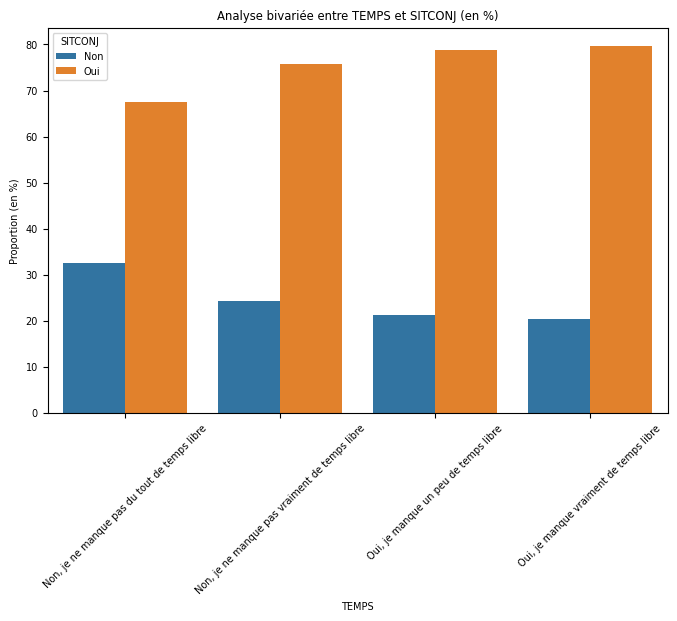

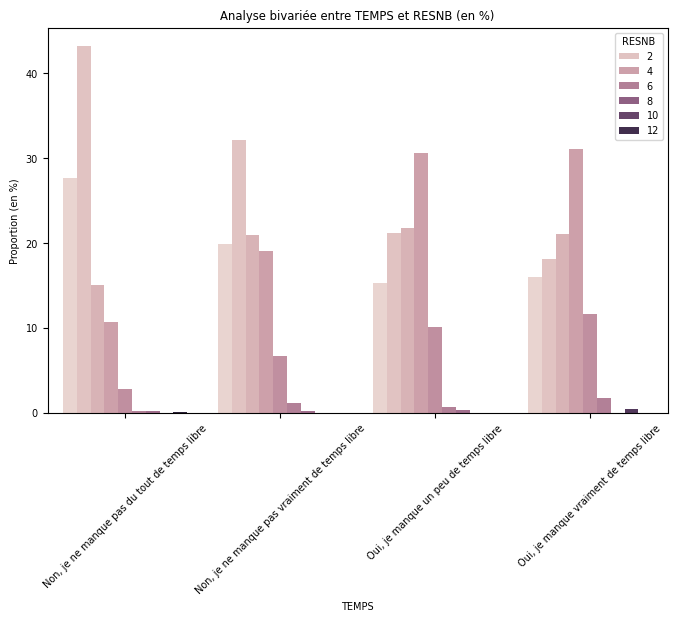

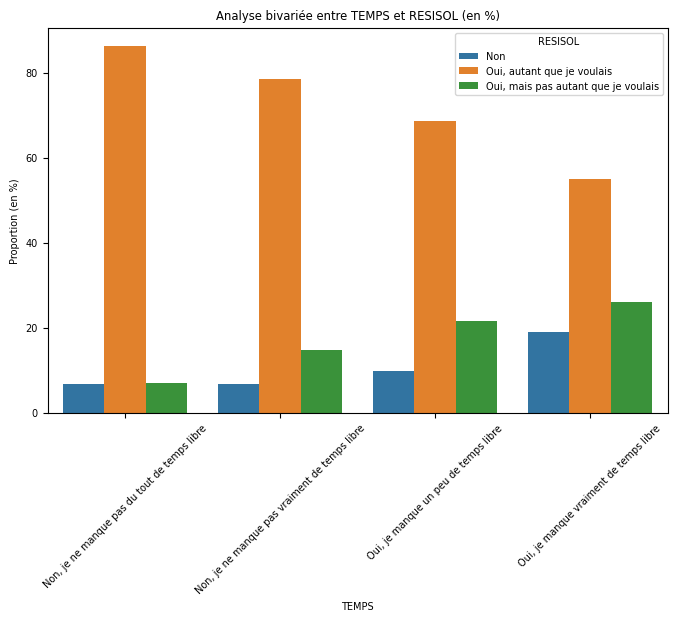

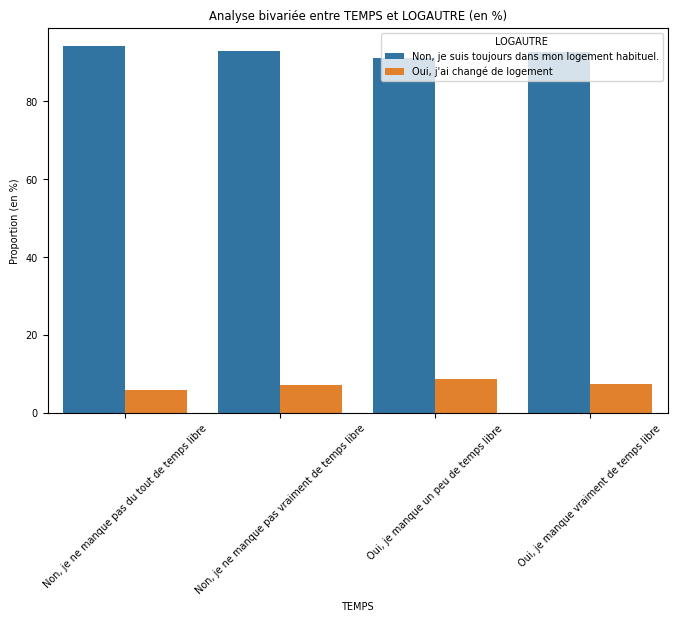

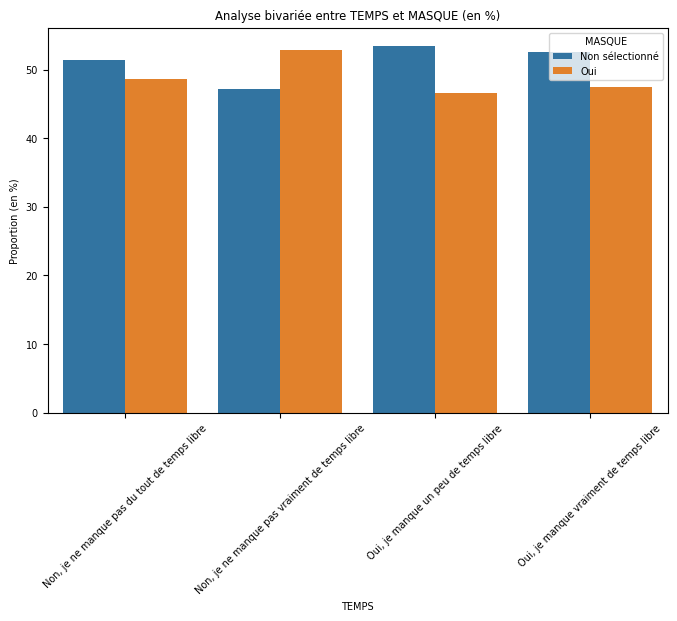

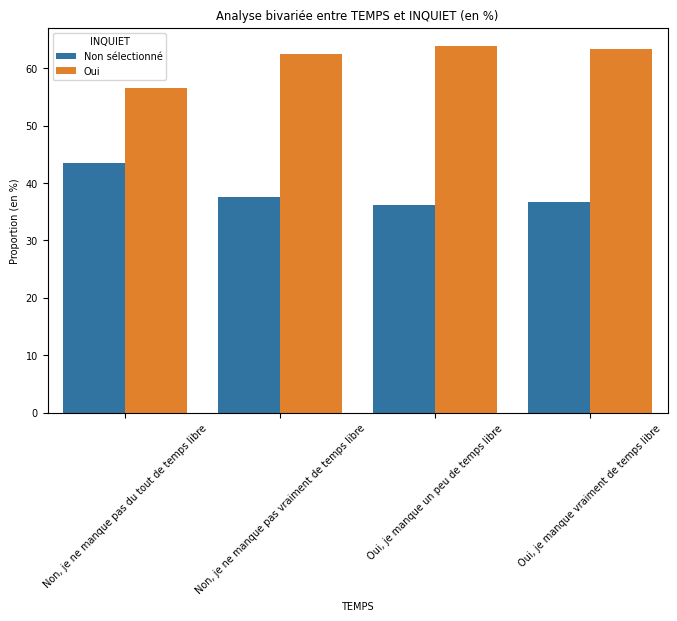

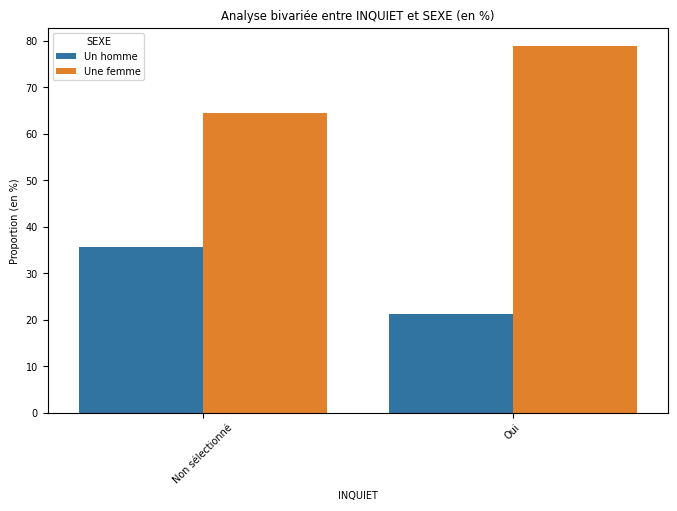

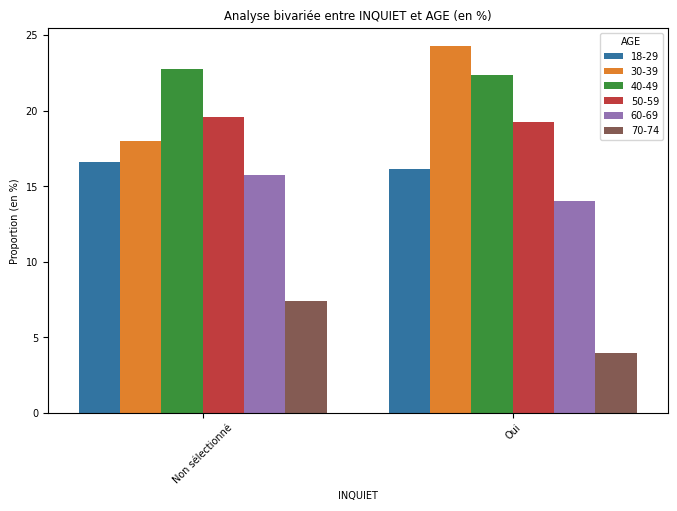

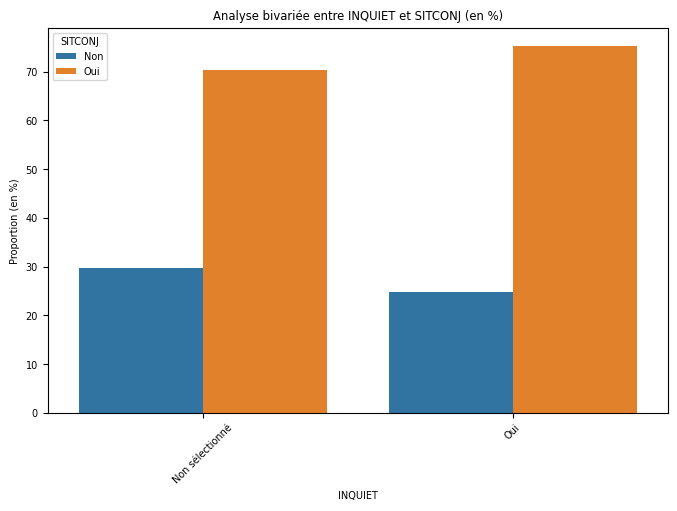

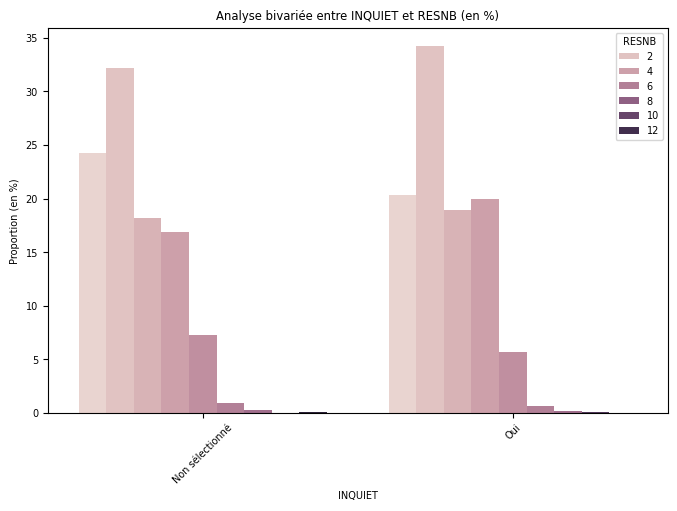

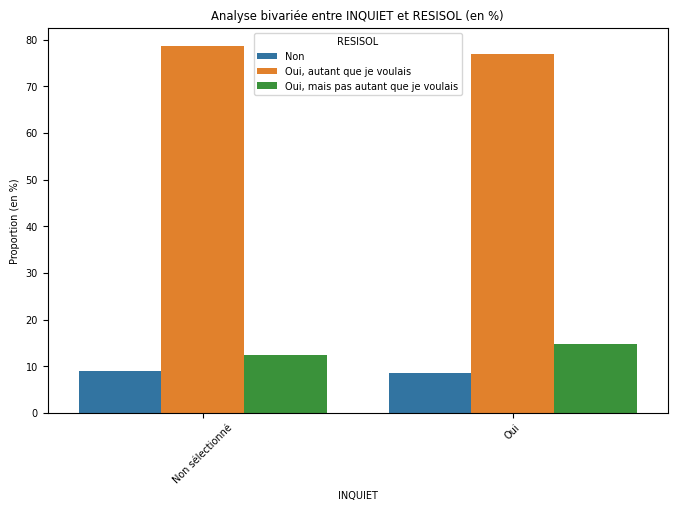

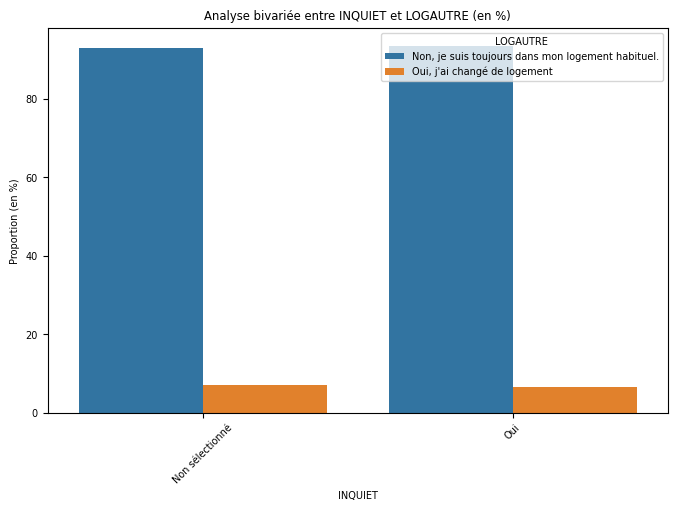

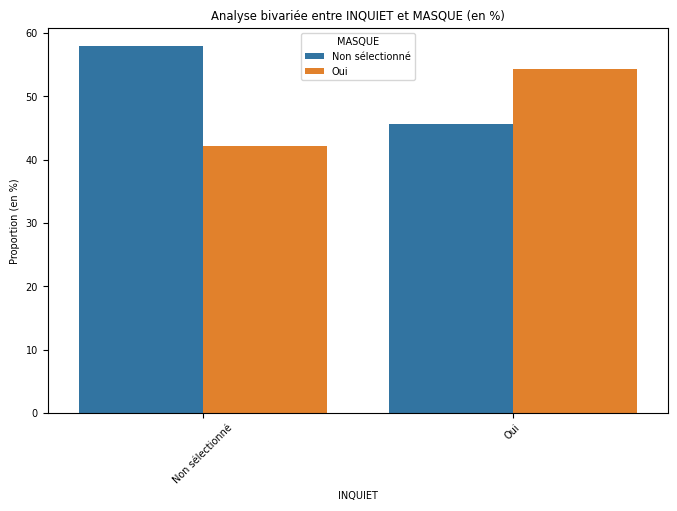

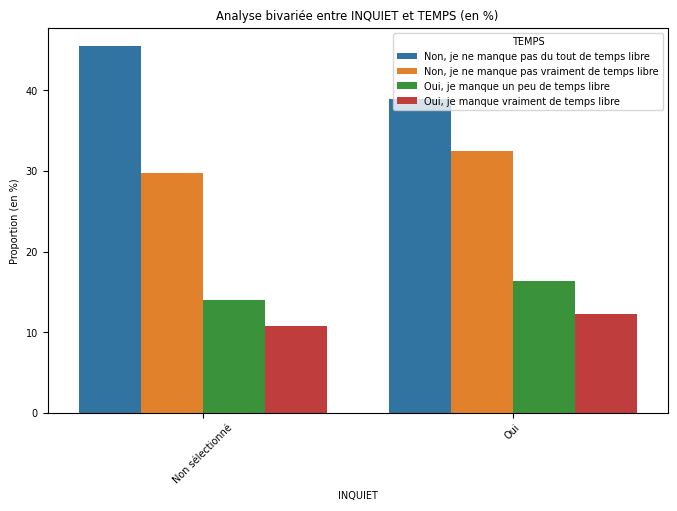

In [28]:
for col1 in df.columns[0:9]:
    for col2 in df.columns[0:9]:
        if col1 != col2: 
            prop = df.groupby([col1, col2]).size()
            prop = prop.reset_index(name="Count")
            prop["Proportion"] = prop["Count"]/prop.groupby(col1)["Count"].transform("sum") * 100

            #Création du graphique
            plt.figure(figsize=(8, 5))
            sns.barplot(x=col1, y="Proportion", hue=col2, data=prop)
            plt.xticks(rotation = 45)
            plt.title(f"Analyse bivariée entre {col1} et {col2} (en %)")
            plt.ylabel("Proportion (en %)")
            plt.show()

### Digression sur la gestion des erreurs

Pour faire cela, nous pouvons nous aider de la matrice de corrélation telle que nous l'avions envisagé dans le cours précédent : 

In [29]:
try:
    df.corr()
except Exception as e:
    print(f"Error : {e}")

Error : could not convert string to float: 'Une femme'


Que s'est-il passé ? Ici, j'ai profité d'une erreur qui allait surgir pour vous montrer comment gérer une erreur potentielle : lorsque vous souhaitez modifier le comportement d'un programme en cas d'erreur, vous pouvez le faire avec le bloc ```try:...except:```.  

Il s'utilise en pratique comme un ```if:...else:``` mais qui possède l'avantage de vous laisser décider du comportement à adopter en cas d'erreur. Ici, j'ai ajouté la précision ```except Exception as e``` afin qu'il stocke le message d'erreur dans la variable e que je peux réutiliser après comme je l'ai fait ici. Cela donne un message d'erreur plus concis.

### Matrice de corrélation

Reprenons : si le code ci-dessus n'a pas fonctionné, c'est parce qu'une matrice de corrélation ne peut s'appliquer que pour des variables quantitatives. 

Nous pouvons donc ici encoder nos variables qualitatives pour les transformer en valeur numériques, comme nous l'avions fait pour la variable de genre lors du cours précédent. Pour cela, construisons un dictionnaire nous permettant de nous rappeler la concordance code/étiquette : 
- Dans un boucle tournant sur toutes les variables de df
- Appliquer les commandes ```.astype("category").cat.categories``` et ```.astype("category").cat.codes``` en les stockant progressivement comme clés/valeurs

In [30]:
for column in df.columns:
    print(f"Modalités de la variable {column}")
    print(df[column].value_counts(dropna=False).sort_index())
    print("==================================")

Modalités de la variable SEXE
SEXE
Un homme      538
Une femme    1462
Name: count, dtype: int64
Modalités de la variable AGE
AGE
18-29    326
30-39    435
40-49    450
50-59    388
60-69    294
70-74    107
Name: count, dtype: int64
Modalités de la variable SITCONJ
SITCONJ
Non     533
Oui    1462
NaN       5
Name: count, dtype: int64
Modalités de la variable RESNB
RESNB
1     438
2     668
3     373
4     374
5     126
6      15
7       4
11      1
13      1
Name: count, dtype: int64
Modalités de la variable RESISOL
RESISOL
Non                                     173
Oui, autant que je voulais             1546
Oui, mais pas autant que je voulais     276
NaN                                       5
Name: count, dtype: int64
Modalités de la variable LOGAUTRE
LOGAUTRE
Non, je suis toujours dans mon logement habituel.    1863
Oui, j'ai changé de logement                          137
Name: count, dtype: int64
Modalités de la variable MASQUE
MASQUE
Non sélectionné    1011
Oui                

In [31]:
df_encoded = df.copy()

Ensuite, procédons effectivement à l'encodage !

Ensuite, procédons au encodage !

In [38]:
from sklearn.preprocessing import LabelEncoder
#On initialise l'encodeur
label_encoder = LabelEncoder()

#On créé le dictionnaire qui conservera les concordances
dico_codes = {}

#On démarre une boucle
for column in df.columns:
    #On récupère les noms des modalités (les étiquettes)
    code = df[column].astype("category").cat.categories

    #On leur assigne un code via l'encodeur
    keys = label_encoder.fit_transform(code)
    
    #On initialise un dictionnaire qui accueillera les couples étiquette/code
    concord = {}

    #Pour chaque étiquette/code, on les ajoute à concord
    for i, e in zip(keys, code):
        concord[i] = e

    #On ajoute le contenu de concord dans une entrée du dictionnaire
    dico_codes[column] = concord

    #On en profite pour effectivement appliquer les codes dans notre dataframe
    df_encoded[column] = label_encoder.fit_transform(df[column])

# On affiche par exemple le dictionnaire constitué
dico_codes

{'SEXE': {np.int64(0): 'Un homme', np.int64(1): 'Une femme'},
 'AGE': {np.int64(0): '18-29',
  np.int64(1): '30-39',
  np.int64(2): '40-49',
  np.int64(3): '50-59',
  np.int64(4): '60-69',
  np.int64(5): '70-74'},
 'SITCONJ': {np.int64(0): 'Non', np.int64(1): 'Oui'},
 'RESNB': {np.int64(0): 1,
  np.int64(1): 2,
  np.int64(2): 3,
  np.int64(3): 4,
  np.int64(4): 5,
  np.int64(5): 6,
  np.int64(6): 7,
  np.int64(7): 11,
  np.int64(8): 13},
 'RESISOL': {np.int64(0): 'Non',
  np.int64(1): 'Oui, autant que je voulais',
  np.int64(2): 'Oui, mais pas autant que je voulais'},
 'LOGAUTRE': {np.int64(0): 'Non, je suis toujours dans mon logement habituel.',
  np.int64(1): "Oui, j'ai changé de logement"},
 'MASQUE': {np.int64(0): 'Non sélectionné', np.int64(1): 'Oui'},
 'TEMPS': {np.int64(0): 'Non, je ne manque pas du tout de temps libre',
  np.int64(1): 'Non, je ne manque pas vraiment de temps libre',
  np.int64(2): 'Oui, je manque un peu de temps libre',
  np.int64(3): 'Oui, je manque vraiment d

Affichons d'ailleurs ce dataframe désormais bien modifié : 

In [39]:
df_encoded.head()

,SEXE,AGE,SITCONJ,RESNB,RESISOL,LOGAUTRE,MASQUE,TEMPS,INQUIET,VOISINS,CONTROL,AMIS,FAMILLE,POL,DIPLONIV,SITPROF_rec,PCS_rec6,REV,POIDS_init
0,1,1,0,0,1,0,0,0,0,0,0,1,2,3,2,0,2,0,1
1,1,1,0,4,2,0,0,2,1,1,2,0,2,2,1,4,2,0,2
2,1,0,0,1,1,0,1,1,0,0,0,2,1,1,2,0,2,8,1
3,1,2,1,1,1,0,0,0,0,0,0,2,2,1,1,3,5,7,2
4,1,3,0,0,1,0,0,1,0,0,0,1,1,4,2,3,2,5,1


L'avantage est qu'avec la création simultanée du dictionnaire, on peut désormais vérifier à tout moment un code vu dans le dataframe : voyons un exemple avec la première ligne.

In [40]:
pd.concat([df.loc[0], df_encoded.loc[0]], axis=1, keys=["Original", "Encodage"])

,Original,Encodage
SEXE,Une femme,1
AGE,30-39,1
SITCONJ,Non,0
RESNB,1,0
RESISOL,"Oui, autant que je voulais",1
LOGAUTRE,"Non, je suis toujours dans mon logement habituel.",0
MASQUE,Non sélectionné,0
TEMPS,"Non, je ne manque pas du tout de temps libre",0
INQUIET,Non sélectionné,0
VOISINS,Non sélectionné,0


In [41]:
dico_codes["DIPLONIV"][3]

'CAP/BEP'

Nous avons donc pu très rapidement encoder nos variables qualitatives en valeur numériques interprétables.

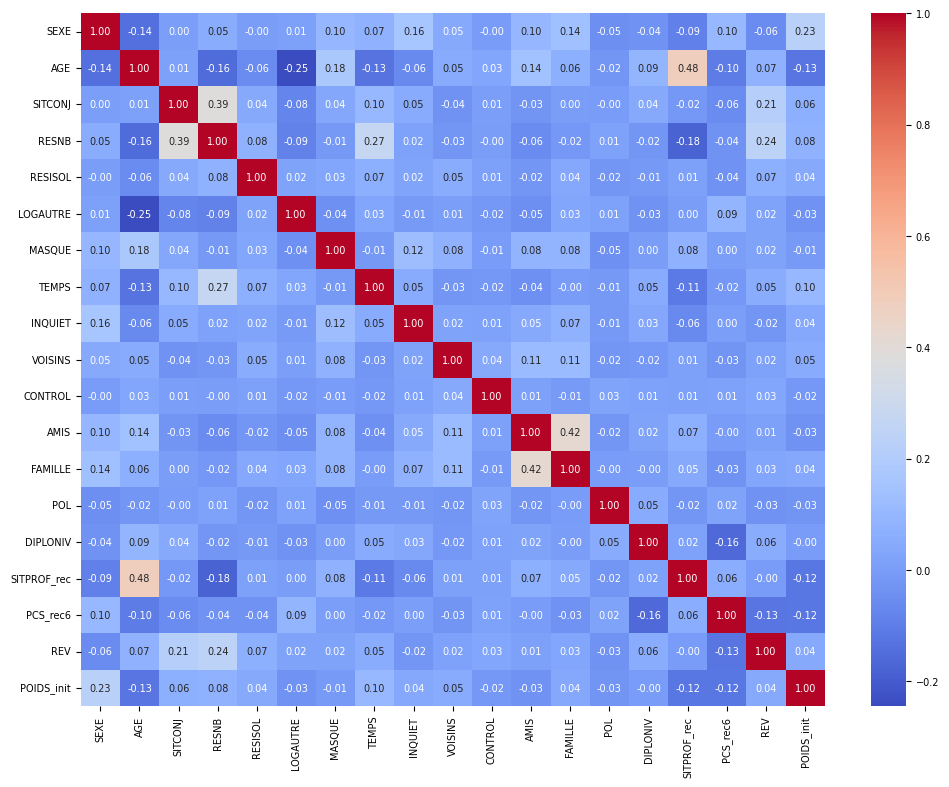

In [42]:
plt.figure(figsize=(12, 9))
sns.heatmap(df_encoded.corr(), cmap='coolwarm', annot=True, fmt = ".2f")
plt.show()

Interessant mais nous constatons rapidement qu'il y a énormément de variables : la fonction ```.corr()``` nous permet de la coupler avec ```.nlargest()``` afin d'obtenir un nombre de variable souhaité.

In [66]:
#Nous souhaitons les 10 variables les plus corrélées à la variable DIPLONIV 
n_corr = df_encoded.corr().nlargest(10, 'MASQUE')['MASQUE'].index
n_corr

Index(['MASQUE', 'AGE', 'INQUIET', 'SEXE', 'AMIS', 'FAMILLE', 'SITPROF_rec',
       'VOISINS', 'SITCONJ', 'RESISOL'],
      dtype='str')

In [67]:
matrice_corr = df_encoded[n_corr].corr()
matrice_corr

,MASQUE,AGE,INQUIET,SEXE,AMIS,FAMILLE,SITPROF_rec,VOISINS,SITCONJ,RESISOL
MASQUE,1.000000,0.177230,0.119770,0.097067,0.083473,0.081057,0.079447,0.077320,0.036057,0.027284
AGE,0.177230,1.000000,-0.064808,-0.139722,0.141131,0.064993,0.481980,0.046781,0.009564,-0.056285
INQUIET,0.119770,-0.064808,1.000000,0.158658,0.045047,0.073290,-0.064823,0.019317,0.050008,0.023308
SEXE,0.097067,-0.139722,0.158658,1.000000,0.097852,0.135818,-0.092683,0.045506,0.004971,-0.001414
AMIS,0.083473,0.141131,0.045047,0.097852,1.000000,0.420000,0.069803,0.112466,-0.027464,-0.022866
FAMILLE,0.081057,0.064993,0.073290,0.135818,0.420000,1.000000,0.046683,0.110444,0.000539,0.038461
SITPROF_rec,0.079447,0.481980,-0.064823,-0.092683,0.069803,0.046683,1.000000,0.008208,-0.018805,0.011075
VOISINS,0.077320,0.046781,0.019317,0.045506,0.112466,0.110444,0.008208,1.000000,-0.035871,0.053856
SITCONJ,0.036057,0.009564,0.050008,0.004971,-0.027464,0.000539,-0.018805,-0.035871,1.000000,0.043854
RESISOL,0.027284,-0.056285,0.023308,-0.001414,-0.022866,0.038461,0.011075,0.053856,0.043854,1.000000


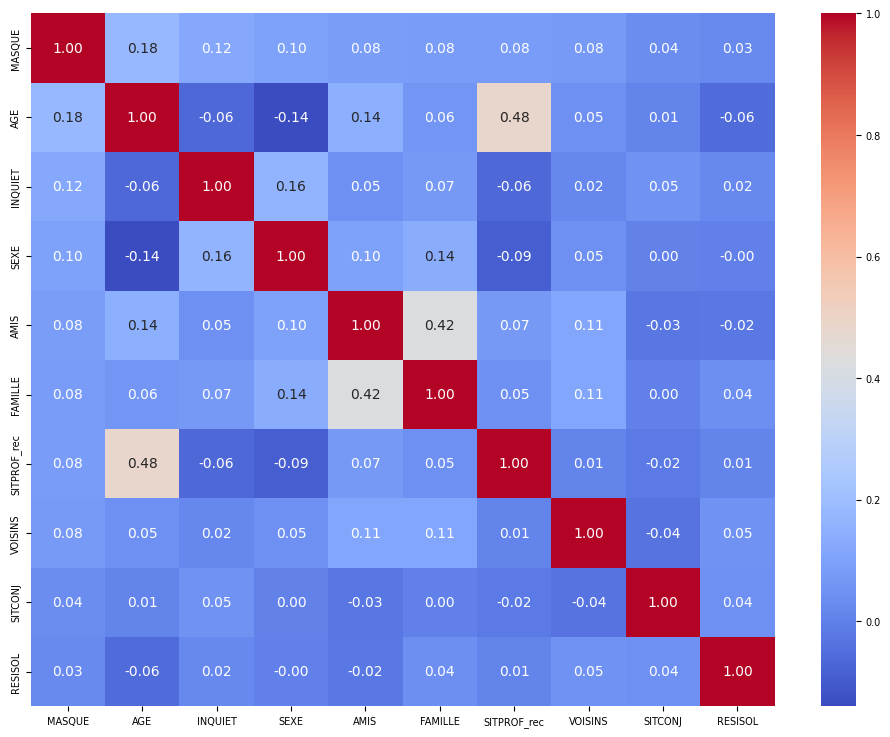

In [68]:
plt.figure(figsize=(12, 9))
sns.heatmap(matrice_corr, cbar=True, cmap='coolwarm', annot=True, fmt='.2f', annot_kws={'size': 10})
plt.show()

## Conclusion

Vous connaissez désormais les bases de la programmation en Python (1er cours), vous avez découvert les librairies principales que sont *Numpy*, *Pandas*, *Matplotlib* et *Seaborn* pour analyser vos données (2ème cours), et avez appliqué ces connaissance pour explorer le jeu de données que nous venons de voir.

Notez qu'il s'agissait d'une introduction qui avait avant tout pour objectif de vous **familiariser avec le langage de programmation et ses grands concepts**, de sorte à vous rendre autonome sur d'autres jeux de données ou sur d'autres tâches. 

L'analyse qualitative/textuelle, les bases de l'intelligence artificielle ou encore l'automatisation de tâches répétitives sont autant de possibilités à explorer en plus de ce que nous venons de voir sur les bases de l'analyse quantitative. N'hésitez pas à vous aider d'internet pour acquérir de nouvelles commandes et découvrir de nouvelles librairies !

N'hésitez pas non plus à me contacter en cas de question sur le cours, et/ou sur la manière d'adapter ce que nous avons vu à votre projet de recherche personnel éventuel.

```python
print("Bonne continuation !")
```